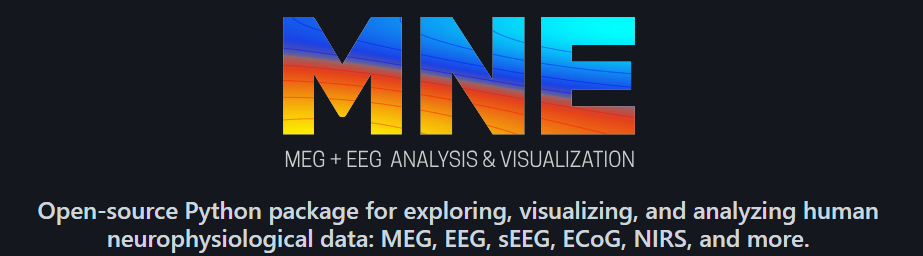

MNE-Python is an open-source Python library for processing, analyzing, and visualizing electrophysiological data such as EEG, MEG, and ECoG. It provides tools for preprocessing, artifact removal, source localization, and feature extraction, making it a powerful framework for neuroscience and brain-computer interface research.

In [7]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 42.9 MB/s eta 0:00:00


In [8]:
import mne
# Import other libraries
import os
import matplotlib.pyplot as plt
from scipy import signal # Nos permite realizar preprocesmaiento de la señal

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
#raw_path = '/content/drive/MyDrive/sub-001_ses-t1_task-resteyesc_eeg.edf'
#raw_path ='/content/drive/MyDrive/Señales/S001_Task2_PREP_Left.set'
#raw_path ='/content/drive/MyDrive/Señales/sub-001_task-motion_run-10_eeg.set'
#raw_path ='/content/drive/MyDrive/Señales/S001R01.edf'
#raw_path ='/content/drive/MyDrive/Señales/S001R04.edf'
#raw_path ='/content/eeg-motor-movementimagery-dataset-1.0.0.zip'
sample_data_folder = mne.datasets.sample.data_path()
raw_path = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
print(f"Using MNE sample dataset: {raw_path}")

Using MNE sample dataset: /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif


In [9]:
print(os.path.exists(raw_path))

False


Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 993 samples (1.653 s)

Frecuencia de mu

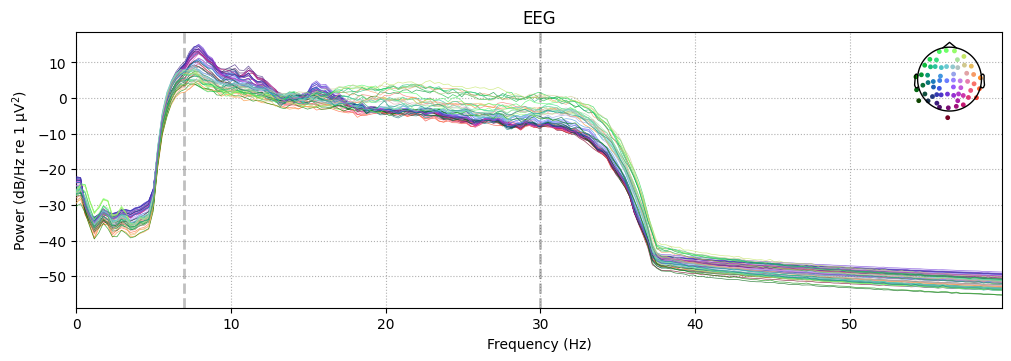

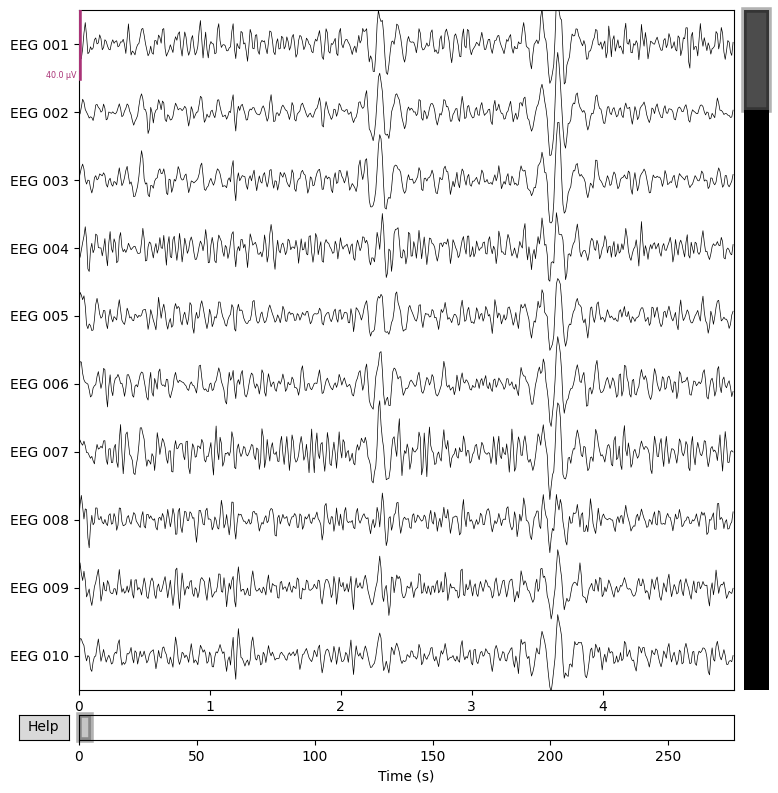

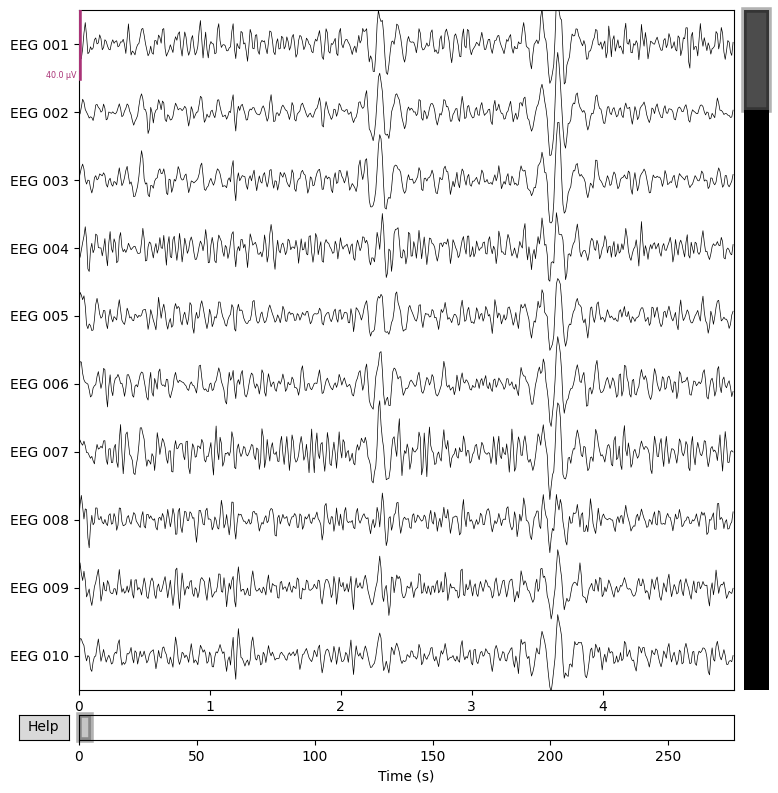

In [93]:
import zipfile
import os

# Cargar el archivo .fif (MNE sample dataset)
# Cargamos tanto EEG como STIM (estímulos) para no perder los eventos
raw = mne.io.read_raw_fif(raw_path, preload=True)

# Mantener canales EEG y el canal de estímulo STI 014
raw.pick_types(eeg=True, meg=False, stim=True, exclude='bads')

# Aplicar un filtro de banda (7-30 Hz)
raw.filter(7., 30., fir_design='firwin')

# Ver información técnica
print(f"Frecuencia de muestreo: {raw.info['sfreq']} Hz")
print(f"Canales disponibles: {raw.ch_names[:10]} ...")

# Visualizar los resultados (PSD y Señal en el tiempo)
raw.compute_psd(fmax=60).plot()
raw.plot(n_channels=10, duration=5, title='Señal EEG Filtrada (7-30 Hz)')

In [96]:
# Obtener el resumen estadístico del DataFrame de épocas
print("Resumen estadístico de las épocas (df_epochs):")
display(df_epochs.describe())

Resumen estadístico de las épocas (df_epochs):


,time,epoch,STI 001,STI 002,STI 003,STI 004,STI 005,STI 006,STI 014,STI 015,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
count,61045.000000,61045.000000,61045.000000,61045.000000,61045.0,61045.0,61045.0,61045.000000,61045.000000,61045.0,...,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000
mean,0.149846,156.627586,0.050045,0.050864,0.0,0.0,0.0,0.004914,0.061807,0.0,...,0.088723,0.070857,0.058764,0.043881,0.042889,0.030672,0.018466,0.012837,0.024450,-0.015350
std,0.202347,92.767426,0.497720,0.501735,0.0,0.0,0.0,0.156679,1.026337,0.0,...,7.006943,6.571136,5.584164,7.528707,7.226710,6.392116,6.899758,6.594375,6.671416,5.344391
min,-0.199795,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,-38.697839,-38.240481,-37.115127,-46.975044,-41.498021,-41.442601,-41.567528,-35.909858,-38.203513,-26.976774
25%,-0.024974,75.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,-3.900913,-3.761918,-3.295155,-4.096299,-4.025424,-3.655145,-3.808727,-3.670027,-3.771456,-2.934839
50%,0.149846,155.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.278424,0.199507,0.161908,0.161093,0.213129,0.145787,0.077305,0.095202,0.147216,-0.101782
75%,0.324667,237.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,4.424782,4.146058,3.557580,4.410091,4.402074,3.938180,3.975959,3.880340,3.946924,2.785404
max,0.499488,317.000000,5.000000,5.000000,0.0,0.0,0.0,5.000000,32.000000,0.0,...,29.197977,28.501403,26.952352,33.291521,33.339131,32.266253,34.015892,33.762502,33.269740,31.591699


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


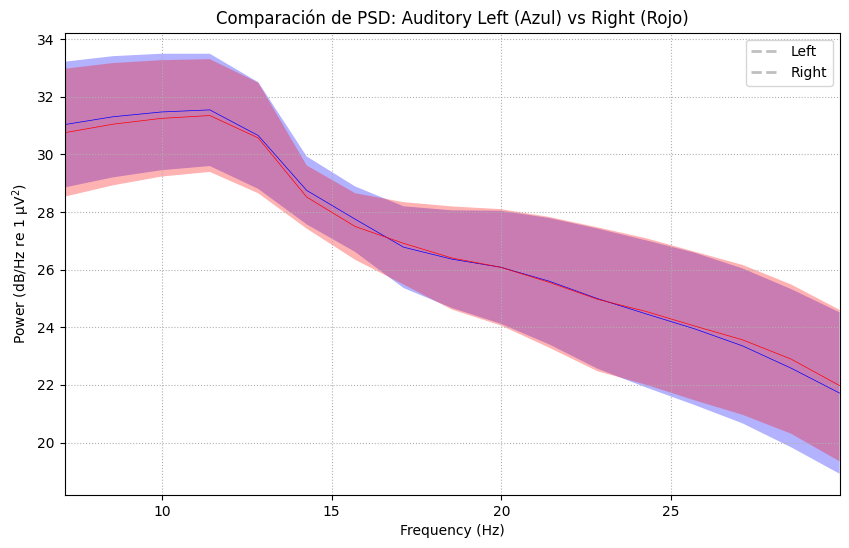

In [94]:
import matplotlib.pyplot as plt

# 1. Definimos el rango de frecuencias de interés (7-30 Hz como el filtro previo)
fmin, fmax = 7.0, 30.0

# 2. Creamos una figura para comparar ambos espectros
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Calculamos y graficamos el PSD promedio para Auditory/Left
psd_left = epochs['Auditory/Left'].compute_psd(fmin=fmin, fmax=fmax, picks='eeg')
psd_left.plot(axes=ax, color='blue', show=False, average=True)

# 4. Calculamos y graficamos el PSD promedio para Auditory/Right
psd_right = epochs['Auditory/Right'].compute_psd(fmin=fmin, fmax=fmax, picks='eeg')
psd_right.plot(axes=ax, color='red', show=False, average=True)

# Personalizamos la gráfica
ax.set_title('Comparación de PSD: Auditory Left (Azul) vs Right (Rojo)')
ax.legend(['Left', 'Right'])
plt.show()

In [34]:
import pandas as pd

# Get the raw data as a NumPy array
data = raw.get_data()

# Get the channel names
channel_names = raw.ch_names

# Create a pandas DataFrame from the data, with channel names as columns
df_raw_data = pd.DataFrame(data.T, columns=channel_names)

# Display descriptive statistics
display(df_raw_data.describe())

,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
count,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,...,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05,1.668000e+05
mean,2.105532e-10,8.327304e-10,1.475001e-09,2.315058e-10,1.925459e-09,1.724695e-09,1.733629e-09,3.533066e-10,1.455510e-09,1.483673e-09,...,5.697559e-10,3.696110e-10,1.846715e-10,-1.773739e-11,1.088591e-10,2.730804e-10,-1.478020e-10,-1.861107e-10,-6.121053e-11,-3.504617e-10
std,6.190018e-06,5.287446e-06,5.445413e-06,6.529056e-06,5.607077e-06,5.898861e-06,7.046122e-06,6.038931e-06,6.518012e-06,5.913241e-06,...,7.416848e-06,7.044631e-06,6.272382e-06,8.667178e-06,7.955712e-06,7.375379e-06,7.933879e-06,7.353757e-06,7.495773e-06,5.828715e-06
min,-3.551526e-05,-3.025047e-05,-3.194746e-05,-3.299377e-05,-3.434200e-05,-2.985303e-05,-3.162498e-05,-4.346785e-05,-3.760056e-05,-3.595838e-05,...,-4.085410e-05,-4.128362e-05,-3.719634e-05,-5.864017e-05,-5.558816e-05,-5.536641e-05,-5.456318e-05,-4.707481e-05,-5.540969e-05,-3.331292e-05
25%,-3.956578e-06,-3.150280e-06,-3.226149e-06,-4.268846e-06,-3.523903e-06,-3.679787e-06,-4.473253e-06,-3.945936e-06,-4.226362e-06,-3.757131e-06,...,-4.114476e-06,-3.967695e-06,-3.585958e-06,-4.614515e-06,-4.333645e-06,-4.068083e-06,-4.284323e-06,-4.040554e-06,-4.128146e-06,-3.166880e-06
50%,-1.601577e-08,2.362177e-08,-2.803556e-08,2.732984e-11,-1.362825e-08,4.070863e-09,1.381616e-09,3.343143e-08,-2.636652e-08,-7.485116e-09,...,2.205948e-07,1.576536e-07,1.176168e-07,1.399120e-07,1.921472e-07,1.325176e-07,9.517266e-08,1.188340e-07,1.137955e-07,-4.722034e-08
75%,3.912612e-06,3.123238e-06,3.232995e-06,4.225269e-06,3.554887e-06,3.644569e-06,4.489767e-06,3.947699e-06,4.232850e-06,3.706585e-06,...,4.453021e-06,4.237304e-06,3.765154e-06,4.912537e-06,4.598082e-06,4.281548e-06,4.464557e-06,4.186468e-06,4.273977e-06,3.042901e-06
max,3.775257e-05,3.498648e-05,3.508581e-05,3.533837e-05,3.505418e-05,3.117706e-05,4.064331e-05,3.411196e-05,4.822117e-05,4.709675e-05,...,3.472169e-05,3.396779e-05,3.658847e-05,3.969416e-05,3.695128e-05,3.782934e-05,3.864283e-05,3.435858e-05,3.604484e-05,3.833477e-05


In [36]:
raw.ch_names

['EEG 001',
 'EEG 002',
 'EEG 003',
 'EEG 004',
 'EEG 005',
 'EEG 006',
 'EEG 007',
 'EEG 008',
 'EEG 009',
 'EEG 010',
 'EEG 011',
 'EEG 012',
 'EEG 013',
 'EEG 014',
 'EEG 015',
 'EEG 016',
 'EEG 017',
 'EEG 018',
 'EEG 019',
 'EEG 020',
 'EEG 021',
 'EEG 022',
 'EEG 023',
 'EEG 024',
 'EEG 025',
 'EEG 026',
 'EEG 027',
 'EEG 028',
 'EEG 029',
 'EEG 030',
 'EEG 031',
 'EEG 032',
 'EEG 033',
 'EEG 034',
 'EEG 035',
 'EEG 036',
 'EEG 037',
 'EEG 038',
 'EEG 039',
 'EEG 040',
 'EEG 041',
 'EEG 042',
 'EEG 043',
 'EEG 044',
 'EEG 045',
 'EEG 046',
 'EEG 047',
 'EEG 048',
 'EEG 049',
 'EEG 050',
 'EEG 051',
 'EEG 052',
 'EEG 054',
 'EEG 055',
 'EEG 056',
 'EEG 057',
 'EEG 058',
 'EEG 059',
 'EEG 060']

In [37]:
raw

<Raw | sample_audvis_raw.fif, 59 x 166800 (277.7 s), ~78.0 MiB, data loaded>

In [38]:
events, event_id = mne.events_from_annotations(raw)

# 2. Mostrar los eventos encontrados para verificar
print("Eventos encontrados en las anotaciones:")
print(event_id)

Eventos encontrados en las anotaciones:
{}


Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
145 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 145 events and 421 original time points ...
0 bad epochs dropped
Total de ensayos segmentados: 145


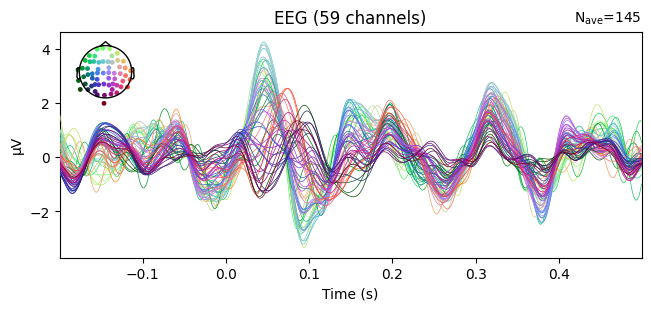

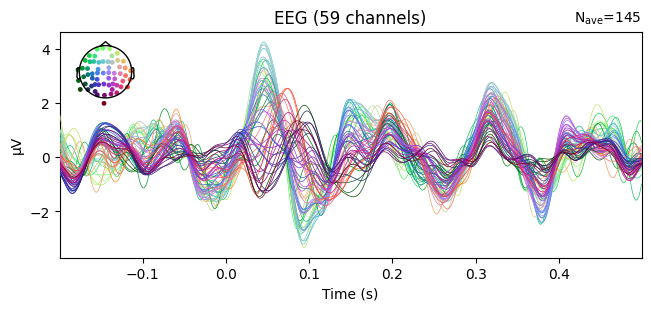

In [52]:
# 1. Buscar eventos en el canal de estímulo (STI 014)
events = mne.find_events(raw, stim_channel='STI 014')

# 2. Definir los IDs de eventos que queremos (Auditivos)
event_id = {'Auditory/Left': 1, 'Auditory/Right': 2}

# 3. Cortar la señal en "Épocas"
epochs = mne.Epochs(raw, events, event_id=event_id, tmin=-0.2, tmax=0.5,
                    baseline=(None, 0), preload=True)

# 4. Mostrar resumen
print(f"Total de ensayos segmentados: {len(epochs)}")

# 5. Graficar el promedio (Evocado) de los canales EEG
epochs.average().plot(picks='eeg')

In [53]:
epochs

<Epochs | 145 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~34.6 MiB, data loaded,
 'Auditory/Left': 72
 'Auditory/Right': 73>

In [54]:
epochs.events

array([[ 27977,      0,      2],
       [ 28771,      0,      1],
       [ 29652,      0,      2],
       [ 30450,      0,      1],
       [ 31240,      0,      2],
       [ 32101,      0,      1],
       [ 32935,      0,      2],
       [ 33712,      0,      1],
       [ 34532,      0,      2],
       [ 35428,      0,      1],
       [ 36211,      0,      2],
       [ 37007,      0,      1],
       [ 37910,      0,      2],
       [ 38711,      0,      1],
       [ 39563,      0,      2],
       [ 40405,      0,      1],
       [ 41260,      0,      2],
       [ 42126,      0,      1],
       [ 42960,      0,      2],
       [ 43781,      0,      1],
       [ 44649,      0,      2],
       [ 45486,      0,      1],
       [ 46240,      0,      2],
       [ 47095,      0,      1],
       [ 47895,      0,      2],
       [ 48722,      0,      1],
       [ 49469,      0,      2],
       [ 50269,      0,      1],
       [ 51046,      0,      2],
       [ 51881,      0,      1],
       [ 5

In [55]:
event_id

{'Auditory/Left': 1, 'Auditory/Right': 2}

In [56]:
events

array([[ 27977,      0,      2],
       [ 28345,      0,      3],
       [ 28771,      0,      1],
       [ 29219,      0,      4],
       [ 29652,      0,      2],
       [ 30025,      0,      3],
       [ 30450,      0,      1],
       [ 30839,      0,      4],
       [ 31240,      0,      2],
       [ 31665,      0,      3],
       [ 32101,      0,      1],
       [ 32519,      0,      4],
       [ 32935,      0,      2],
       [ 33325,      0,      3],
       [ 33712,      0,      1],
       [ 34089,      0,      5],
       [ 34532,      0,      2],
       [ 34649,      0,     32],
       [ 34956,      0,      3],
       [ 35428,      0,      1],
       [ 35850,      0,      4],
       [ 36211,      0,      2],
       [ 36576,      0,      3],
       [ 37007,      0,      1],
       [ 37460,      0,      4],
       [ 37910,      0,      2],
       [ 38326,      0,      3],
       [ 38711,      0,      1],
       [ 39130,      0,      4],
       [ 39563,      0,      2],
       [ 3

Using matplotlib as 2D backend.


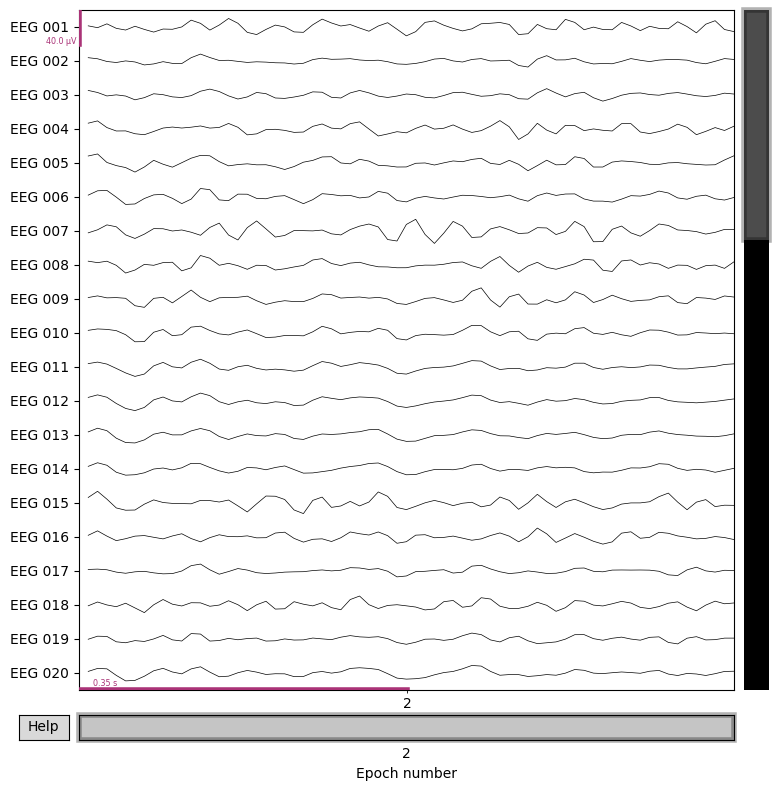

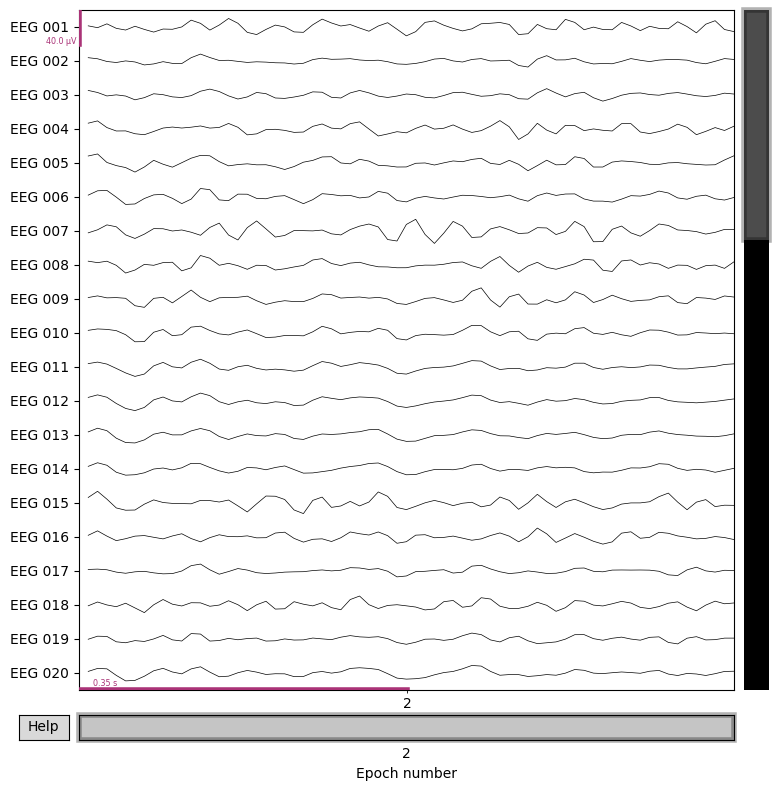

In [57]:
# Seleccionar la segunda época (índice 1)
segunda_epoca = epochs[1]

# Ver la señal de esa época específica
segunda_epoca.plot()

In [60]:
# En MNE, las épocas se seleccionan por su nombre en el diccionario event_id
# En este caso '2' corresponde a 'Auditory/Right'

# Puedes seleccionar todas las épocas de 'Auditory/Right' así:
todas_las_derecha = epochs['Auditory/Right']

# Si quieres la PRIMERA vez que ocurrió ese evento:
primera_derecha = epochs['Auditory/Right'][0]

print(f"Total de ensayos (Auditory/Right): {len(todas_las_derecha)}")

Total de ensayos (Auditory/Right): 73


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_156/36288303.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


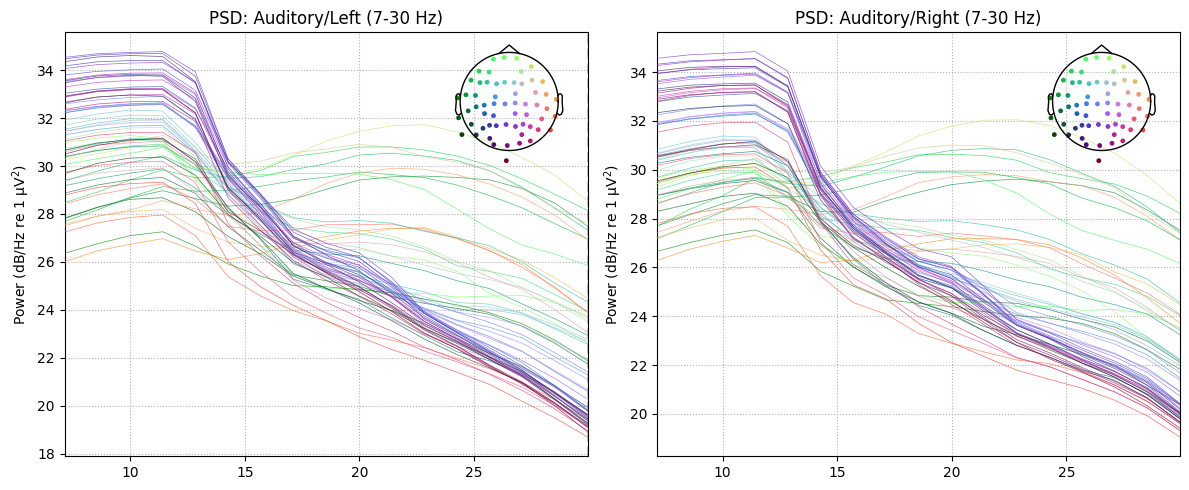

In [62]:
# 1. Graficar el espectro de potencia (PSD) para comparar Auditory Left vs Right
# Esto nos dirá si el filtrado fue correcto y dónde está la energía en el espectro

# Creamos una figura con 2 subplots
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Graficar Espectro para Auditory/Left
psd_left = epochs['Auditory/Left'].compute_psd(fmin=7, fmax=30, picks='eeg')
psd_left.plot(axes=ax[0], show=False)
ax[0].set_title("PSD: Auditory/Left (7-30 Hz)")

# Graficar Espectro para Auditory/Right
psd_right = epochs['Auditory/Right'].compute_psd(fmin=7, fmax=30, picks='eeg')
psd_right.plot(axes=ax[1], show=False)
ax[1].set_title("PSD: Auditory/Right (7-30 Hz)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_156/608433825.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


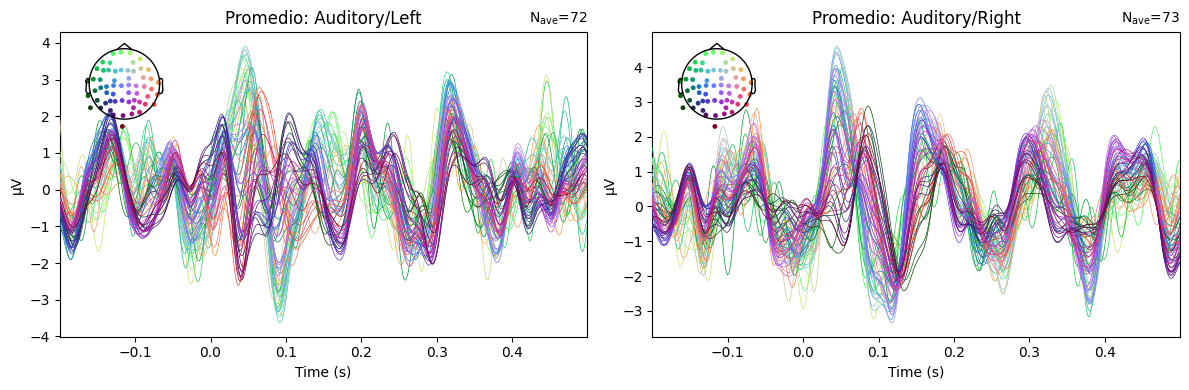

In [66]:
import matplotlib.pyplot as plt

# Creamos los promedios (evocados) usando los nombres correctos
evoked_left = epochs['Auditory/Left'].average()
evoked_right = epochs['Auditory/Right'].average()

# Los comparamos en los canales motores (o una seleccion de EEG si no existen C3/C4)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
evoked_left.plot(picks='eeg', axes=ax[0], spatial_colors=True, show=False)
ax[0].set_title('Promedio: Auditory/Left')
evoked_right.plot(picks='eeg', axes=ax[1], spatial_colors=True, show=False)
ax[1].set_title('Promedio: Auditory/Right')
plt.tight_layout()
plt.show()

## Cargando el .set

In [79]:
import os

# Revisar contenido de la carpeta 'Colab Notebooks' por si el archivo está ahí
colab_dir = '/content/drive/MyDrive/Colab Notebooks/'
if os.path.exists(colab_dir):
    print(f"Archivos en '{colab_dir}':")
    print(os.listdir(colab_dir))
else:
    print("No se encontró la carpeta 'Colab Notebooks'.")

Archivos en '/content/drive/MyDrive/Colab Notebooks/':
['Untitled0.ipynb', 'FILTROS.ipynb', 'Copia de FILTROS.ipynb', 'Copia de TALLER.ipynb', 'Copia de INTENTO 10.ipynb', 'Untitled1.ipynb', 'INTENTO otro.ipynb', 'PRACTICA_1.ipynb', 'PRACTICA_2.ipynb', 'PARCIAL SEÑALES.ipynb', 'Untitled2.ipynb', 'Exploracion_MNE (1).ipynb', '.ipynb_checkpoints', 'Exploracion_MNE.ipynb']


In [80]:
import os

def find_file(name, path):
    for root, dirs, files in os.walk(path):
        if name in files:
            return os.path.join(root, name)
    return None

target_file = 'sub-001_task-motion_run-10_eeg.set'
search_path = '/content/drive/MyDrive/'

print(f"Buscando '{target_file}' en {search_path}...")
result = find_file(target_file, search_path)

if result:
    print(f"¡Archivo encontrado! La ruta es: {result}")
else:
    print("No se encontró el archivo. Por favor, verifica que se haya subido correctamente al Drive.")

Buscando 'sub-001_task-motion_run-10_eeg.set' en /content/drive/MyDrive/...
No se encontró el archivo. Por favor, verifica que se haya subido correctamente al Drive.


In [68]:
import os
# Listar las carpetas en la raíz del Drive para encontrar la ruta correcta
drive_path = '/content/drive/MyDrive/'
if os.path.exists(drive_path):
    print('Carpetas encontradas en tu Drive:')
    print(os.listdir(drive_path))
else:
    print('El Drive no parece estar montado correctamente.')

Carpetas encontradas en tu Drive:
['Colab Notebooks', 'Documento sin título.docx', 'convierte este archivo en excel y organiza la inf....gsheet', 'Resume en una tabla la información de impuestos d....gsheet', 'Hazlo con todas las hojas del pdf.gsheet', '2025-12-02 19-10-48.mp4', 'PRACTICA 3.ipynb']


In [72]:
events, event_id = mne.events_from_annotations(raw)

# A veces en OpenNeuro, las etiquetas ya vienen con nombres claros:
print(f"Eventos encontrados: {event_id}")

Eventos encontrados: {}


In [73]:
# 3. Extraer eventos con los nombres específicos de OpenNeuro
# Mapeamos los nombres largos a etiquetas más cortas y fáciles de usar
id_mapping = {
    'TASK4T0': 1, # Reposo
    'TASK4T1': 2, # Imaginar Mano Izquierda
    'TASK4T2': 3  # Imaginar Mano Derecha
}
events, event_id_dict = mne.events_from_annotations(raw, event_id=id_mapping)

In [74]:
events

array([], shape=(0, 3), dtype=int64)

In [84]:
# 1. Detectar eventos desde el canal de estímulo para asegurar que la variable no esté vacía
events = mne.find_events(raw, stim_channel='STI 014')

# 2. Definir los IDs de eventos que queremos
event_id_mapping = {'Auditory/Left': 1, 'Auditory/Right': 2}

# 3. Crear las Épocas (Epochs)
epochs = mne.Epochs(raw, events,
                    event_id=event_id_mapping,
                    tmin=-0.2, tmax=0.5,
                    baseline=(None, 0),
                    preload=True)

print(f"Total de ensayos segmentados: {len(epochs)}")
print(epochs)

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
145 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 145 events and 421 original time points ...
0 bad epochs dropped
Total de ensayos segmentados: 145
<Epochs | 145 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~34.6 MiB, data loaded,
 'Auditory/Left': 72
 'Auditory/Right': 73>


In [85]:
epochs

<Epochs | 145 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~34.6 MiB, data loaded,
 'Auditory/Left': 72
 'Auditory/Right': 73>

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


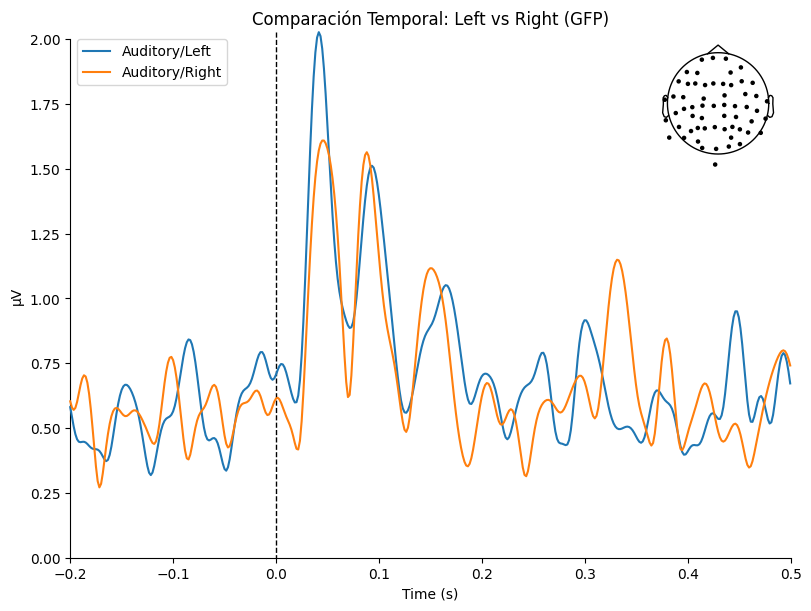

In [88]:
import matplotlib.pyplot as plt

# 1. Creamos los objetos 'Evoked' (promedio) para cada condición
evoked_dict = {
    'Auditory/Left': epochs['Auditory/Left'].average(),
    'Auditory/Right': epochs['Auditory/Right'].average()
}

# 2. Graficamos la comparación en el dominio del tiempo
# Usamos picks='eeg' para ver la respuesta general de los electrodos
mne.viz.plot_compare_evokeds(evoked_dict, picks='eeg',
                             title='Comparación Temporal: Left vs Right',
                             show_sensors='upper right')
plt.show()

In [91]:
import pandas as pd

# 1. Convertir los datos de las épocas a un DataFrame de Pandas
# Esto crea una tabla donde cada fila es un punto de tiempo de un ensayo específico
df_epochs = epochs.to_data_frame()

# 2. Mostrar estadísticas descriptivas (Media, STD, Min, Max, etc.)
# Filtramos para mostrar solo las columnas de los canales EEG
print("Estadísticas descriptivas de la amplitud (microvoltios) por canal:")
display(df_epochs.describe())

Estadísticas descriptivas de la amplitud (microvoltios) por canal:


,time,epoch,STI 001,STI 002,STI 003,STI 004,STI 005,STI 006,STI 014,STI 015,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
count,61045.000000,61045.000000,61045.000000,61045.000000,61045.0,61045.0,61045.0,61045.000000,61045.000000,61045.0,...,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000,61045.000000
mean,0.149846,156.627586,0.050045,0.050864,0.0,0.0,0.0,0.004914,0.061807,0.0,...,0.088723,0.070857,0.058764,0.043881,0.042889,0.030672,0.018466,0.012837,0.024450,-0.015350
std,0.202347,92.767426,0.497720,0.501735,0.0,0.0,0.0,0.156679,1.026337,0.0,...,7.006943,6.571136,5.584164,7.528707,7.226710,6.392116,6.899758,6.594375,6.671416,5.344391
min,-0.199795,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,-38.697839,-38.240481,-37.115127,-46.975044,-41.498021,-41.442601,-41.567528,-35.909858,-38.203513,-26.976774
25%,-0.024974,75.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,-3.900913,-3.761918,-3.295155,-4.096299,-4.025424,-3.655145,-3.808727,-3.670027,-3.771456,-2.934839
50%,0.149846,155.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.278424,0.199507,0.161908,0.161093,0.213129,0.145787,0.077305,0.095202,0.147216,-0.101782
75%,0.324667,237.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,4.424782,4.146058,3.557580,4.410091,4.402074,3.938180,3.975959,3.880340,3.946924,2.785404
max,0.499488,317.000000,5.000000,5.000000,0.0,0.0,0.0,5.000000,32.000000,0.0,...,29.197977,28.501403,26.952352,33.291521,33.339131,32.266253,34.015892,33.762502,33.269740,31.591699


    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


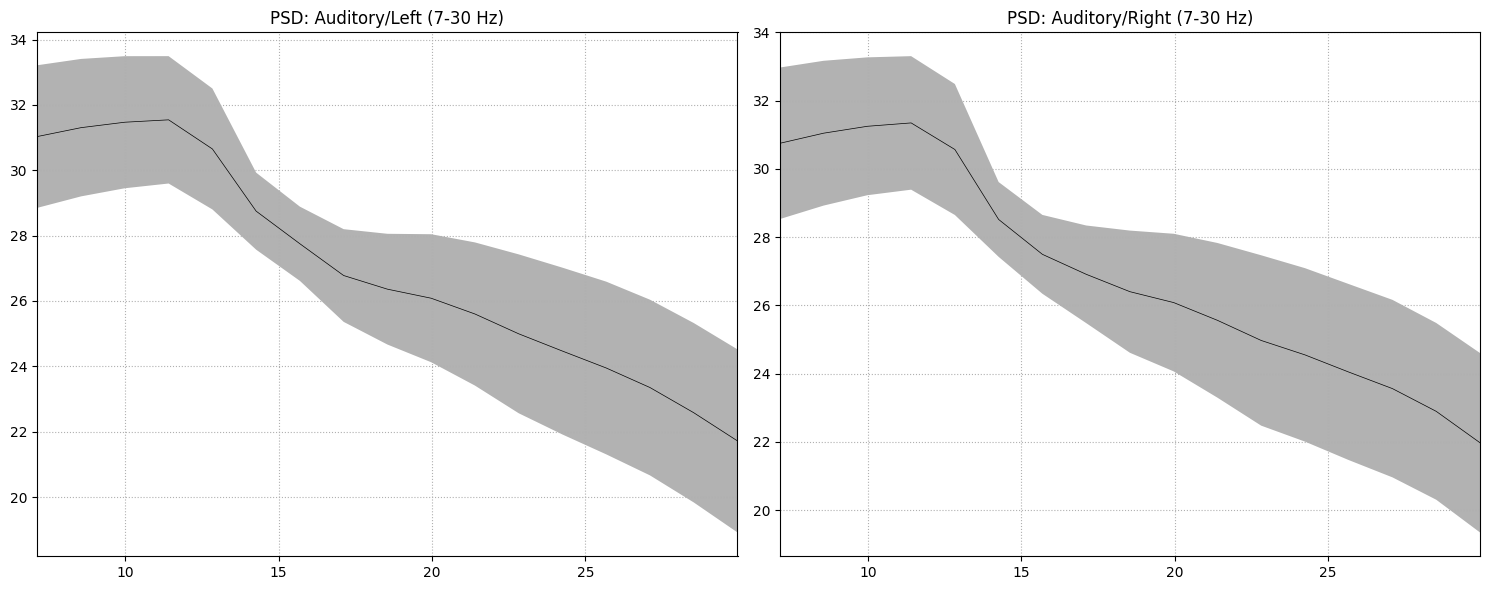

In [99]:
import matplotlib.pyplot as plt

# Crear una figura con dos subplots para comparar
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Calcular y graficar PSD para Auditory/Left
psd_left = epochs['Auditory/Left'].compute_psd(fmin=7, fmax=30, picks='eeg')
psd_left.plot(axes=ax[0], show=False, average=True)
ax[0].set_title('PSD: Auditory/Left (7-30 Hz)')

# Calcular y graficar PSD para Auditory/Right
psd_right = epochs['Auditory/Right'].compute_psd(fmin=7, fmax=30, picks='eeg')
psd_right.plot(axes=ax[1], show=False, average=True)
ax[1].set_title('PSD: Auditory/Right (7-30 Hz)')

plt.tight_layout()
plt.show()

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


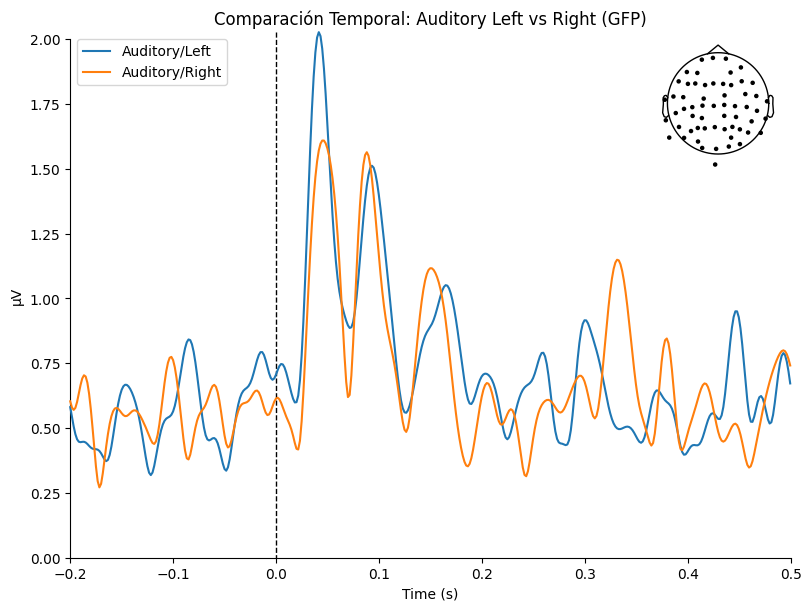

In [97]:
import matplotlib.pyplot as plt

# 1. Creamos un diccionario con los promedios (Evokeds) para cada condición
evoked_dict = {
    'Auditory/Left': epochs['Auditory/Left'].average(),
    'Auditory/Right': epochs['Auditory/Right'].average()
}

# 2. Graficamos la comparación temporal
# Usamos picks='eeg' para ver la respuesta combinada de los electrodos
mne.viz.plot_compare_evokeds(evoked_dict,
                             picks='eeg',
                             title='Comparación Temporal: Auditory Left vs Right',
                             show_sensors='upper right')
plt.show()

## Ejemplo clase

In [101]:
import numpy as np
import pandas as pd

# --- 1. Preparación de datos usando los nombres reales del dataset ---
# 'Auditory/Left' actúa como nuestra 'Mano_Izquierda'
# 'Auditory/Right' actúa como nuestra 'Mano_Derecha'

data_izq = epochs['Auditory/Left'].get_data(copy=False)  # Shape: (n_ensayos, n_canales, n_tiempos)
data_der = epochs['Auditory/Right'].get_data(copy=False) # Shape: (n_ensayos, n_canales, n_tiempos)

# --- 2. Cálculo de RMS por época ---
# Obtenemos la amplitud efectiva de cada canal en cada ensayo
rms_por_epoca_izq = np.sqrt(np.mean(data_izq**2, axis=2))
rms_por_epoca_der = np.sqrt(np.mean(data_der**2, axis=2))

# --- 3. Promedio del Sujeto ---
rms_promedio_izq = rms_por_epoca_izq.mean(axis=0)
rms_promedio_der = rms_por_epoca_der.mean(axis=0)

# --- 4. Organización en DataFrame para visualización ---
df_resultado = pd.DataFrame(
    [rms_promedio_izq, rms_promedio_der],
    index=['Auditory_Left', 'Auditory_Right'],
    columns=epochs.ch_names
)

print("Resumen de Energía (RMS) calculado con éxito:")
display(df_resultado.iloc[:, :10].head()) # Mostramos los primeros 10 canales

Resumen de Energía (RMS) calculado con éxito:


,STI 001,STI 002,STI 003,STI 004,STI 005,STI 006,STI 014,STI 015,STI 016,EEG 001
Auditory_Left,0.70957,0.000000,0.0,0.0,0.0,0.020307,0.268107,0.0,0.0,0.000006
Auditory_Right,0.00000,0.710437,0.0,0.0,0.0,0.048354,0.574689,0.0,0.0,0.000006


In [102]:
data_der.shape

(73, 68, 421)

In [105]:
import numpy as np
import pandas as pd

# --- 1. Preparación de datos ---
# Usamos los nombres reales detectados en el dataset de ejemplo
data_izq = epochs['Auditory/Left'].get_data(copy=False)  # Shape: (n_ensayos, n_canales, n_tiempos)
data_der = epochs['Auditory/Right'].get_data(copy=False) # Shape: (n_ensayos, n_canales, n_tiempos)

# --- 2. Cálculo de RMS por época ---
# Obtenemos la amplitud efectiva de cada canal en cada ensayo
# Resultado shape: (n_ensayos, n_canales)
rms_por_epoca_izq = np.sqrt(np.mean(data_izq**2, axis=2))
rms_por_epoca_der = np.sqrt(np.mean(data_der**2, axis=2))

# --- 3. Promedio del Sujeto (Para el DataFrame Poblacional) ---
# Calculamos la media de la energía a través de todos los ensayos
# Resultado shape: (n_canales,)
rms_promedio_izq = rms_por_epoca_izq.mean(axis=0)
rms_promedio_der = rms_por_epoca_der.mean(axis=0)

# --- 4. Organización en DataFrame ---
# Creamos una fila para cada condición con los resultados por canal
df_sujeto_rms = pd.DataFrame(
    [rms_promedio_izq, rms_promedio_der],
    index=['Auditory_Left', 'Auditory_Right'],
    columns=epochs.ch_names
)

print("Resultados de energía (RMS) por canales y condición:")
display(df_sujeto_rms.head())

Resultados de energía (RMS) por canales y condición:


,STI 001,STI 002,STI 003,STI 004,STI 005,STI 006,STI 014,STI 015,STI 016,EEG 001,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
Auditory_Left,0.70957,0.000000,0.0,0.0,0.0,0.020307,0.268107,0.0,0.0,0.000006,...,0.000006,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005
Auditory_Right,0.00000,0.710437,0.0,0.0,0.0,0.048354,0.574689,0.0,0.0,0.000006,...,0.000007,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005


In [111]:
# Mostrar los valores numéricos de la diferencia (ordenados de mayor a menor)
print("Diferencia de Energía RMS (V) por canal (Left - Right):")
display(rms_diff.sort_values(ascending=False).to_frame(name='RMS_Difference'))

Diferencia de Energía RMS (V) por canal (Left - Right):


,RMS_Difference
EEG 002,4.049836e-07
EEG 003,3.451771e-07
EEG 011,3.272115e-07
EEG 012,2.890193e-07
EEG 006,2.621159e-07
EEG 013,2.452842e-07
EEG 005,2.423205e-07
EEG 014,2.071911e-07
EEG 001,1.895533e-07
EEG 010,1.868519e-07


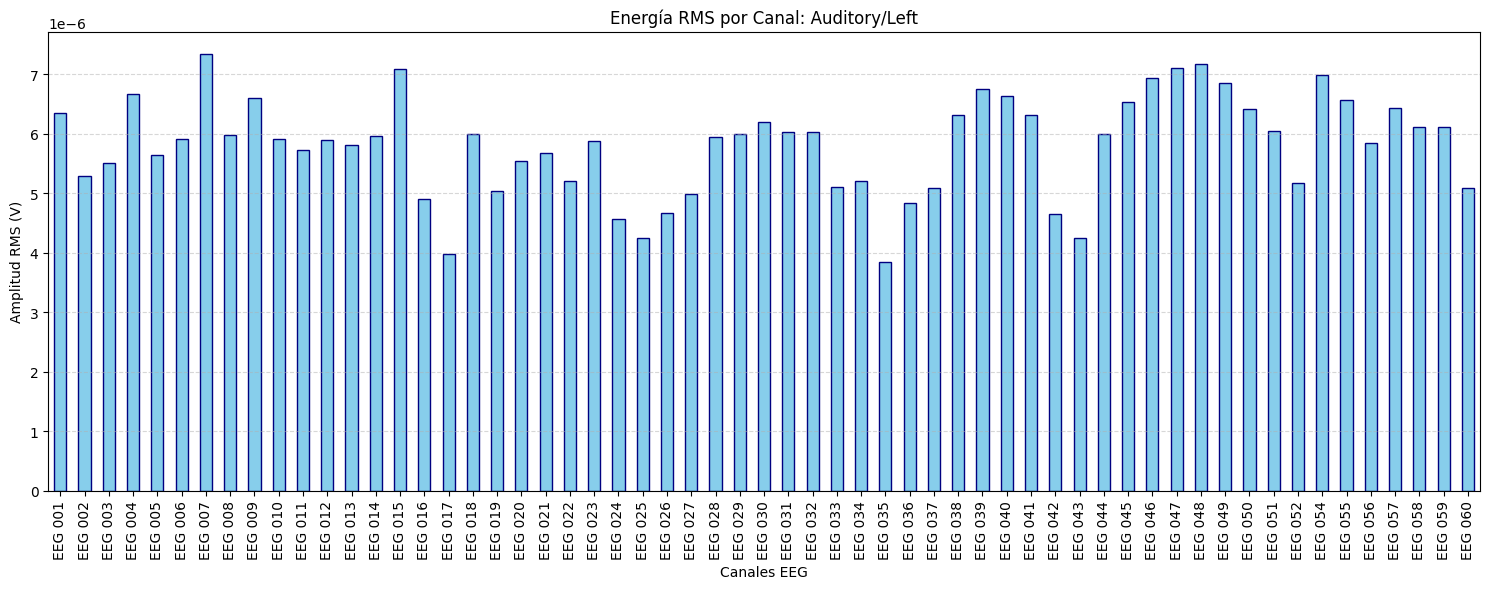

In [108]:
import matplotlib.pyplot as plt

# 1. Extraer los datos de la fila 'Auditory_Left' filtrando solo canales EEG
rms_left_channels = df_sujeto_rms.loc['Auditory_Left', eeg_picks]

# 2. Crear la gráfica de barras por canal
plt.figure(figsize=(15, 6))
rms_left_channels.plot(kind='bar', color='skyblue', edgecolor='navy')

plt.title('Energía RMS por Canal: Auditory/Left')
plt.ylabel('Amplitud RMS (V)')
plt.xlabel('Canales EEG')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

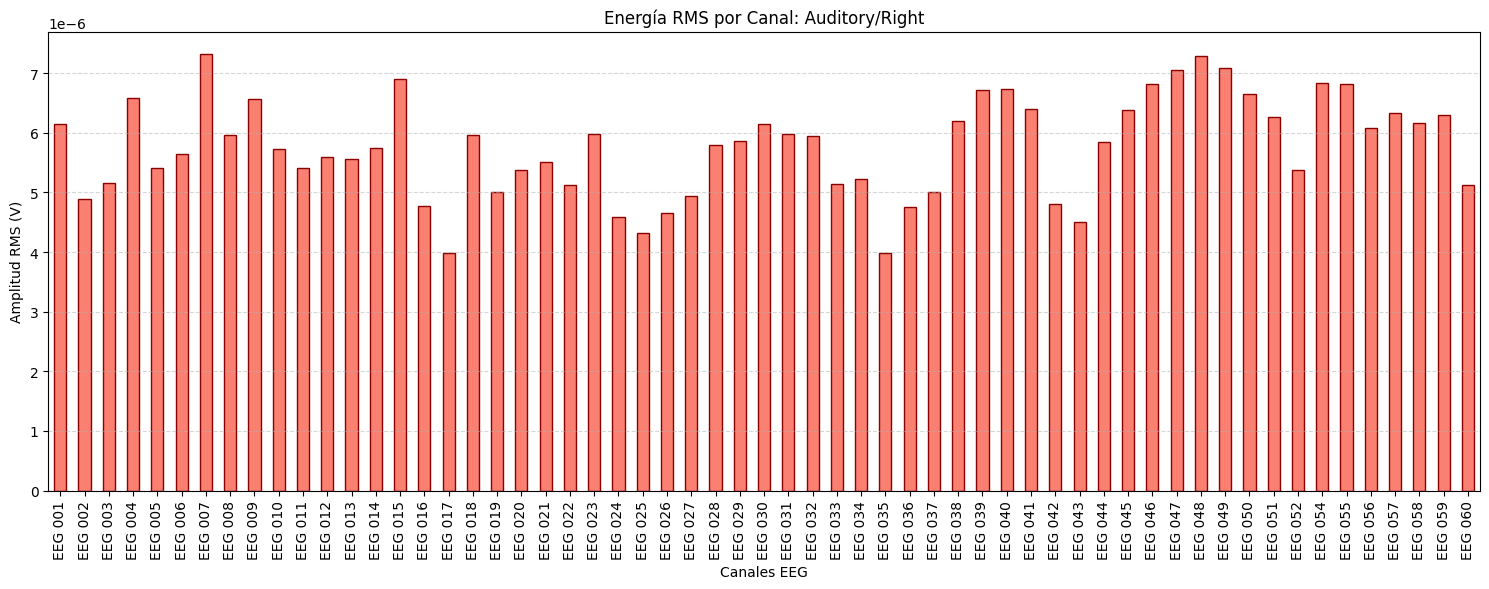

In [109]:
import matplotlib.pyplot as plt

# 1. Extraer los datos de la fila 'Auditory_Right' filtrando solo canales EEG
rms_right_channels = df_sujeto_rms.loc['Auditory_Right', eeg_picks]

# 2. Crear la gráfica de barras por canal
plt.figure(figsize=(15, 6))
rms_right_channels.plot(kind='bar', color='salmon', edgecolor='darkred')

plt.title('Energía RMS por Canal: Auditory/Right')
plt.ylabel('Amplitud RMS (V)')
plt.xlabel('Canales EEG')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

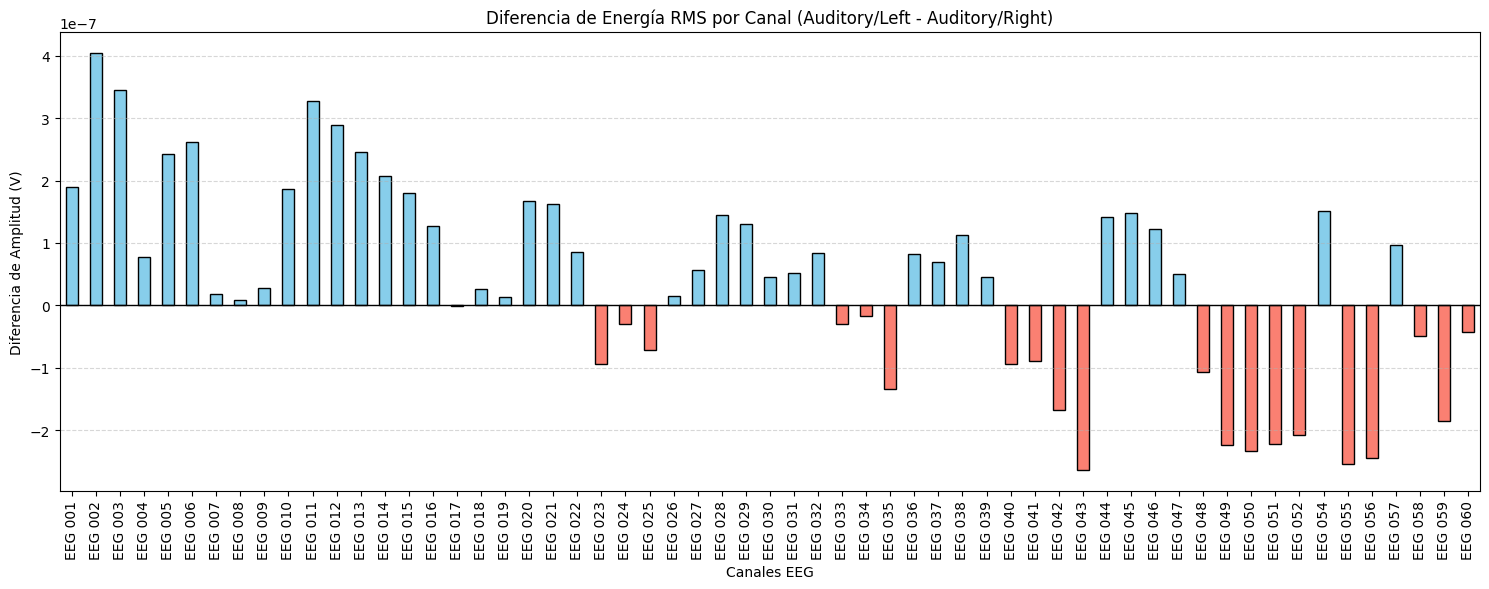

Los canales con valores positivos tuvieron más energía en el estímulo Izquierdo.
Los canales con valores negativos tuvieron más energía en el estímulo Derecho.


In [110]:
import matplotlib.pyplot as plt

# 1. Calcular la diferencia (Resta) por canal entre ambas condiciones
# Valores positivos = Más energía en Left | Valores negativos = Más energía en Right
rms_diff = df_sujeto_rms.loc['Auditory_Left', eeg_picks] - df_sujeto_rms.loc['Auditory_Right', eeg_picks]

# 2. Graficar la diferencia
plt.figure(figsize=(15, 6))
colors = ['skyblue' if val >= 0 else 'salmon' for val in rms_diff]
rms_diff.plot(kind='bar', color=colors, edgecolor='black')

plt.title('Diferencia de Energía RMS por Canal (Auditory/Left - Auditory/Right)')
plt.ylabel('Diferencia de Amplitud (V)')
plt.xlabel('Canales EEG')
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Los canales con valores positivos tuvieron más energía en el estímulo Izquierdo.")
print("Los canales con valores negativos tuvieron más energía en el estímulo Derecho.")

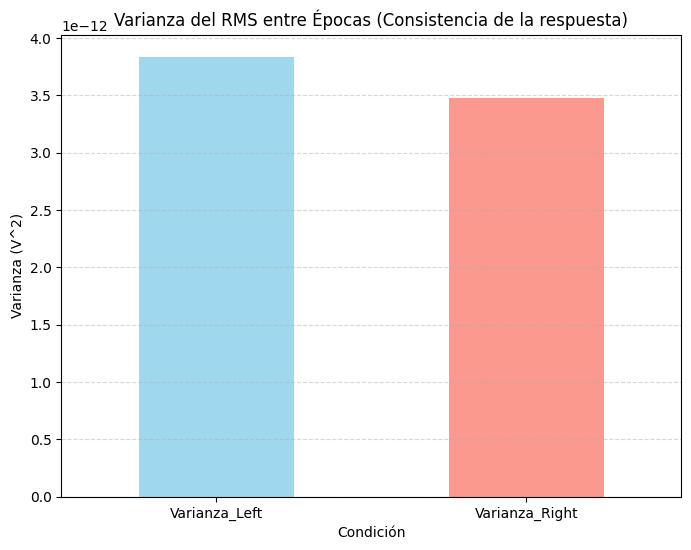

Valores de varianza promedio global:
Varianza_Left     3.837077e-12
Varianza_Right    3.480009e-12
dtype: float64


In [107]:
import matplotlib.pyplot as plt

# 1. Calcular la varianza a través de las épocas para cada canal
# rms_por_epoca tiene forma (n_ensayos, n_canales)
var_izq = np.var(rms_por_epoca_izq, axis=0)
var_der = np.var(rms_por_epoca_der, axis=0)

# 2. Organizar en un DataFrame
df_varianza = pd.DataFrame(
    [var_izq, var_der],
    index=['Varianza_Left', 'Varianza_Right'],
    columns=epochs.ch_names
)

# 3. Calcular la varianza promedio global (solo canales EEG)
var_global = df_varianza[eeg_picks].mean(axis=1)

# 4. Graficar la comparación de varianza
plt.figure(figsize=(8, 6))
var_global.plot(kind='bar', color=['skyblue', 'salmon'], alpha=0.8)
plt.title('Varianza del RMS entre Épocas (Consistencia de la respuesta)')
plt.ylabel('Varianza (V^2)')
plt.xlabel('Condición')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print("Valores de varianza promedio global:")
print(var_global)

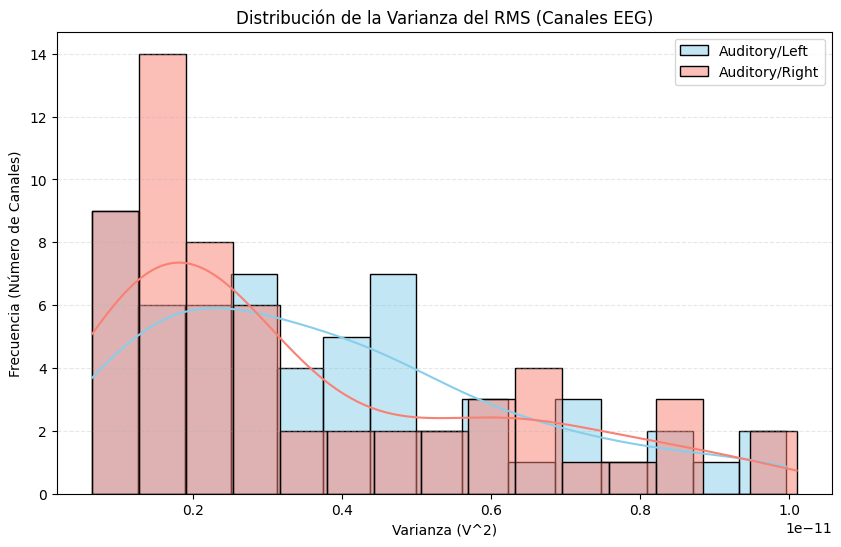

Estadísticas de la distribución de varianza (Left):
count    5.900000e+01
mean     3.837077e-12
std      2.458381e-12
min      6.438924e-13
25%      1.862369e-12
50%      3.300871e-12
75%      5.184829e-12
max      9.953153e-12
Name: Varianza_Left, dtype: float64

Estadísticas de la distribución de varianza (Right):
count    5.900000e+01
mean     3.480009e-12
std      2.587634e-12
min      6.446532e-13
25%      1.580629e-12
50%      2.138831e-12
75%      5.438642e-12
max      1.010049e-11
Name: Varianza_Right, dtype: float64


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos de varianza (solo canales EEG)
var_left_vals = df_varianza.loc['Varianza_Left', eeg_picks]
var_right_vals = df_varianza.loc['Varianza_Right', eeg_picks]

# 2. Crear la figura
plt.figure(figsize=(10, 6))

# 3. Graficar histogramas con curva de densidad (KDE)
sns.histplot(var_left_vals, color='skyblue', label='Auditory/Left', kde=True, bins=15, alpha=0.5)
sns.histplot(var_right_vals, color='salmon', label='Auditory/Right', kde=True, bins=15, alpha=0.5)

plt.title('Distribución de la Varianza del RMS (Canales EEG)')
plt.xlabel('Varianza (V^2)')
plt.ylabel('Frecuencia (Número de Canales)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("Estadísticas de la distribución de varianza (Left):")
print(var_left_vals.describe())
print("\nEstadísticas de la distribución de varianza (Right):")
print(var_right_vals.describe())

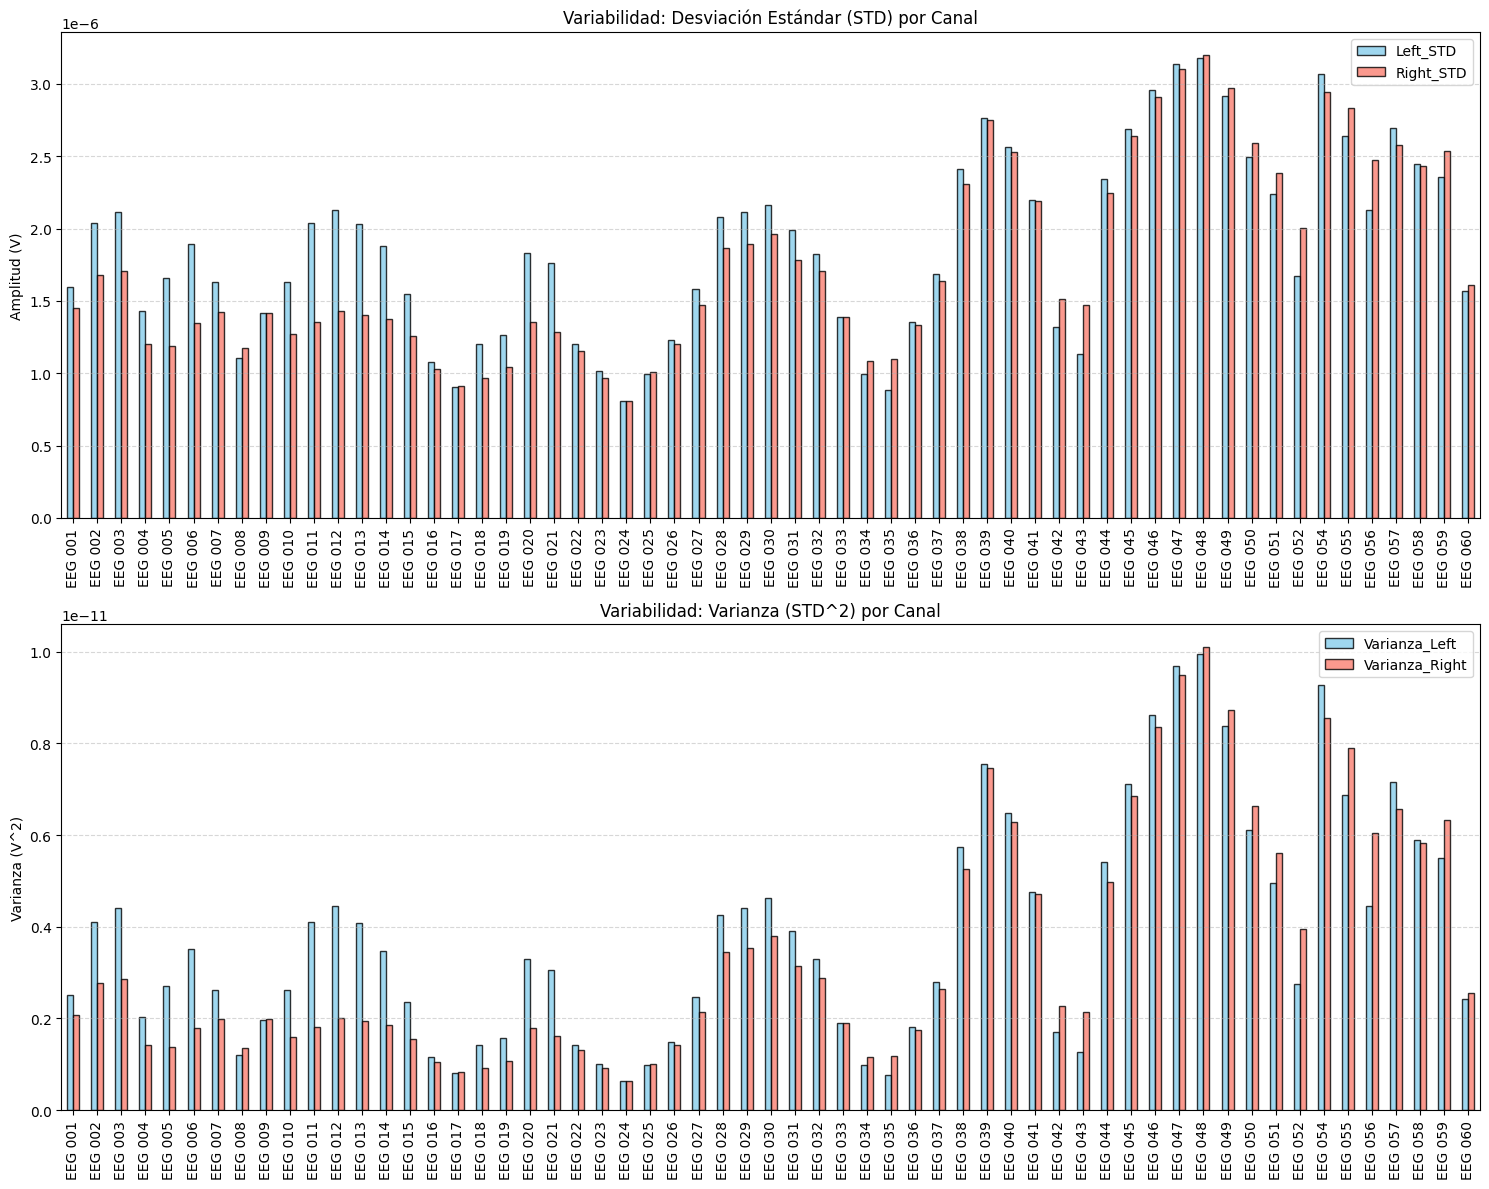

In [121]:
import matplotlib.pyplot as plt

# 1. Preparamos los datos de varianza para graficar (solo canales EEG)
df_var_comp = df_varianza[eeg_picks].T

# 2. Creamos una figura con dos subplots (uno para STD y otro para Varianza)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Graficamos la Desviación Estándar (STD)
df_std_comp.plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'], edgecolor='black', alpha=0.8)
ax1.set_title('Variabilidad: Desviación Estándar (STD) por Canal')
ax1.set_ylabel('Amplitud (V)')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Graficamos la Varianza
df_var_comp.plot(kind='bar', ax=ax2, color=['skyblue', 'salmon'], edgecolor='black', alpha=0.8)
ax2.set_title('Variabilidad: Varianza (STD^2) por Canal')
ax2.set_ylabel('Varianza (V^2)')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

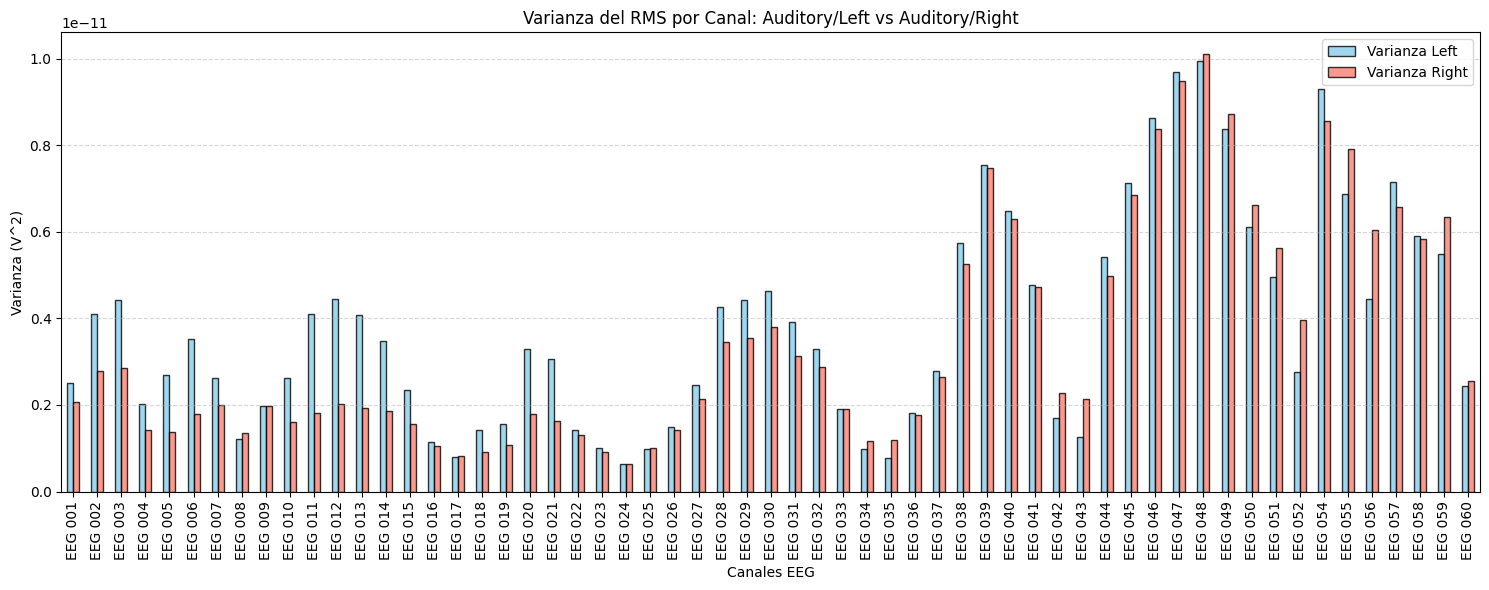

In [120]:
import matplotlib.pyplot as plt

# 1. Transponer el DataFrame para que los canales sean el índice y las condiciones las columnas
# Filtramos solo por los canales EEG previamente identificados
df_var_plot = df_varianza[eeg_picks].T

# 2. Graficar la comparación por canal
ax = df_var_plot.plot(kind='bar', figsize=(15, 6), color=['skyblue', 'salmon'], edgecolor='black', alpha=0.8)

plt.title('Varianza del RMS por Canal: Auditory/Left vs Auditory/Right')
plt.ylabel('Varianza (V^2)')
plt.xlabel('Canales EEG')
plt.legend(['Varianza Left', 'Varianza Right'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [119]:
import pandas as pd

# Mostrar el DataFrame completo generado en pasos anteriores
print("Tabla de Energía RMS Representativa (Sujeto):")
display(df_sujeto_rms)

Tabla de Energía RMS Representativa (Sujeto):


,STI 001,STI 002,STI 003,STI 004,STI 005,STI 006,STI 014,STI 015,STI 016,EEG 001,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
Auditory_Left,0.70957,0.000000,0.0,0.0,0.0,0.020307,0.268107,0.0,0.0,0.000006,...,0.000006,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005
Auditory_Right,0.00000,0.710437,0.0,0.0,0.0,0.048354,0.574689,0.0,0.0,0.000006,...,0.000007,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005


In [112]:
import numpy as np

def calculate_rms_per_epoch(epoch_data):
    """
    Calcula el RMS para cada época y cada canal individualmente.

    Parámetros:
    epoch_data (numpy.ndarray): Arreglo de forma (n_epochs, n_channels, n_times)

    Retorna:
    numpy.ndarray: Matriz de RMS con forma (n_epochs, n_channels)
    """
    # 1. Elevar al cuadrado todos los valores de amplitud
    squared_data = np.power(epoch_data, 2)

    # 2. Calcular la media sobre el eje del tiempo (axis=2)
    mean_squared = np.mean(squared_data, axis=2)

    # 3. Calcular la raíz cuadrada
    rms_values = np.sqrt(mean_squared)

    return rms_values

# Ejemplo de uso con los datos actuales:
data_izq = epochs['Auditory/Left'].get_data(copy=False)
rms_matrix = calculate_rms_per_epoch(data_izq)

print(f"Forma de los datos originales: {data_izq.shape} (Ensayos, Canales, Tiempo)")
print(f"Forma de la matriz RMS resultante: {rms_matrix.shape} (Ensayos, Canales)")
print("\nPrimeras 5 filas del RMS para el primer canal:")
print(rms_matrix[:5, 0])

Forma de los datos originales: (72, 68, 421) (Ensayos, Canales, Tiempo)
Forma de la matriz RMS resultante: (72, 68) (Ensayos, Canales)

Primeras 5 filas del RMS para el primer canal:
[0.68924552 0.73105527 0.73105527 0.68924552 0.68924552]


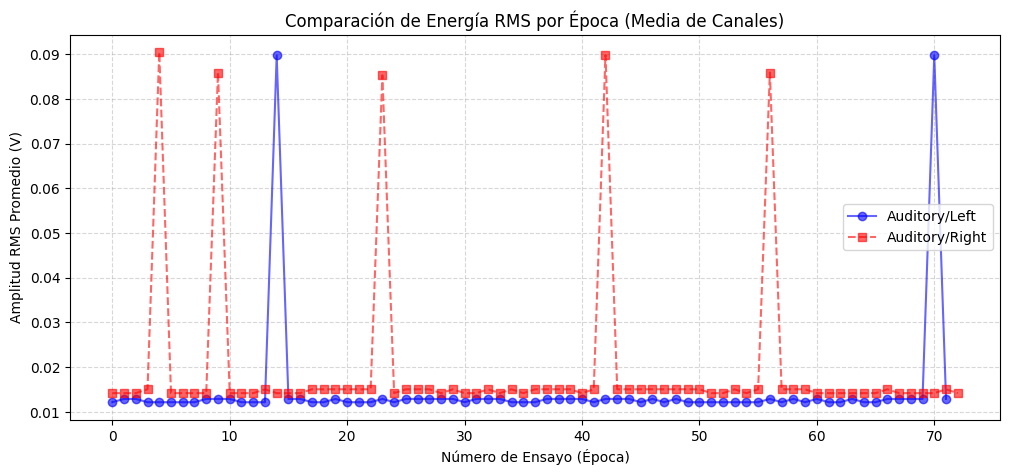

Media RMS global (Izquierda): 1.47e-02 V
Media RMS global (Derecha): 1.96e-02 V


In [114]:
import matplotlib.pyplot as plt

# 1. Obtener datos de ambas condiciones
data_left = epochs['Auditory/Left'].get_data(copy=False)
data_right = epochs['Auditory/Right'].get_data(copy=False)

# 2. Aplicar nuestra función personalizada para obtener las matrices (n_epochs, n_channels)
rms_matrix_left = calculate_rms_per_epoch(data_left)
rms_matrix_right = calculate_rms_per_epoch(data_right)

# 3. Calcular la media sobre canales para cada época (n_epochs,)
# Esto nos da un valor de energía 'global' por cada ensayo
mean_rms_epochs_left = np.mean(rms_matrix_left, axis=1)
mean_rms_epochs_right = np.mean(rms_matrix_right, axis=1)

# 4. Graficar la comparación de los ensayos
plt.figure(figsize=(12, 5))
plt.plot(mean_rms_epochs_left, label='Auditory/Left', color='blue', marker='o', linestyle='-', alpha=0.6)
plt.plot(mean_rms_epochs_right, label='Auditory/Right', color='red', marker='s', linestyle='--', alpha=0.6)

plt.title('Comparación de Energía RMS por Época (Media de Canales)')
plt.xlabel('Número de Ensayo (Época)')
plt.ylabel('Amplitud RMS Promedio (V)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Media RMS global (Izquierda): {np.mean(mean_rms_epochs_left):.2e} V")
print(f"Media RMS global (Derecha): {np.mean(mean_rms_epochs_right):.2e} V")

In [118]:
import numpy as np

def calculate_subject_representative_rms(epoch_data):
    """
    Calcula el RMS para cada época/canal y luego promedia a través
    de las épocas para obtener un valor representativo del sujeto.

    Parámetros:
    epoch_data (numpy.ndarray): Arreglo de forma (n_epochs, n_channels, n_times)

    Retorna:
    numpy.ndarray: Vector de forma (n_channels,) con el promedio del sujeto.
    """
    # 1. Calcular el RMS individual (n_epochs, n_channels)
    # Reutilizamos la lógica anterior: sqrt(mean(x^2))
    rms_matrix = np.sqrt(np.mean(np.square(epoch_data), axis=2))

    # 2. Promediar a través de las épocas (axis=0)
    # Esto nos da el valor representativo por canal
    subject_representative = np.mean(rms_matrix, axis=0)

    return subject_representative

# Ejemplo de uso:
rep_rms_left = calculate_subject_representative_rms(data_left)
rep_rms_right = calculate_subject_representative_rms(data_right)

print(f"Forma del resultado: {rep_rms_left.shape} (Un valor por canal)")
print("\nValores representativos (RMS Promedio) de los primeros 5 canales (Left):")
for ch_name, val in zip(epochs.ch_names[:5], rep_rms_left[:5]):
    print(f"{ch_name}: {val:.2e} V")

Forma del resultado: (68,) (Un valor por canal)

Valores representativos (RMS Promedio) de los primeros 5 canales (Left):
STI 001: 7.10e-01 V
STI 002: 0.00e+00 V
STI 003: 0.00e+00 V
STI 004: 0.00e+00 V
STI 005: 0.00e+00 V


In [123]:
import numpy as np
import pandas as pd

# 1. Asegurarnos de tener la lista de canales EEG (ya definida anteriormente)
eeg_picks = [ch for ch in epochs.ch_names if 'EEG' in ch]

# 2. Extraer los datos de las épocas filtrando solo por canales EEG
data_eeg_left = epochs['Auditory/Left'].get_data(picks=eeg_picks, copy=False)
data_eeg_right = epochs['Auditory/Right'].get_data(picks=eeg_picks, copy=False)

# 3. Calcular la matriz RMS (Ensayos x Canales EEG) usando la primera función
rms_matrix_eeg_left = calculate_rms_per_epoch(data_eeg_left)
rms_matrix_eeg_right = calculate_rms_per_epoch(data_eeg_right)

# 4. Calcular el vector representativo (Promedio del Sujeto por Canal) usando la segunda función
rep_rms_eeg_left = calculate_subject_representative_rms(data_eeg_left)
rep_rms_eeg_right = calculate_subject_representative_rms(data_eeg_right)

# 5. Organizar los resultados representativos en un DataFrame para visualización
df_eeg_rms_results = pd.DataFrame(
    [rep_rms_eeg_left, rep_rms_eeg_right],
    index=['EEG_Auditory_Left', 'EEG_Auditory_Right'],
    columns=eeg_picks
)

print(f"Forma de la matriz RMS (Left): {rms_matrix_eeg_left.shape} (Ensayos, Canales EEG)")
print(f"Forma del vector representativo: {rep_rms_eeg_left.shape} (Canales EEG)")
print("\nPrimeros 10 canales del resumen representativo (EEG):")
display(df_eeg_rms_results.iloc[:, :10])

Forma de la matriz RMS (Left): (72, 59) (Ensayos, Canales EEG)
Forma del vector representativo: (59,) (Canales EEG)

Primeros 10 canales del resumen representativo (EEG):


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010
EEG_Auditory_Left,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006
EEG_Auditory_Right,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006


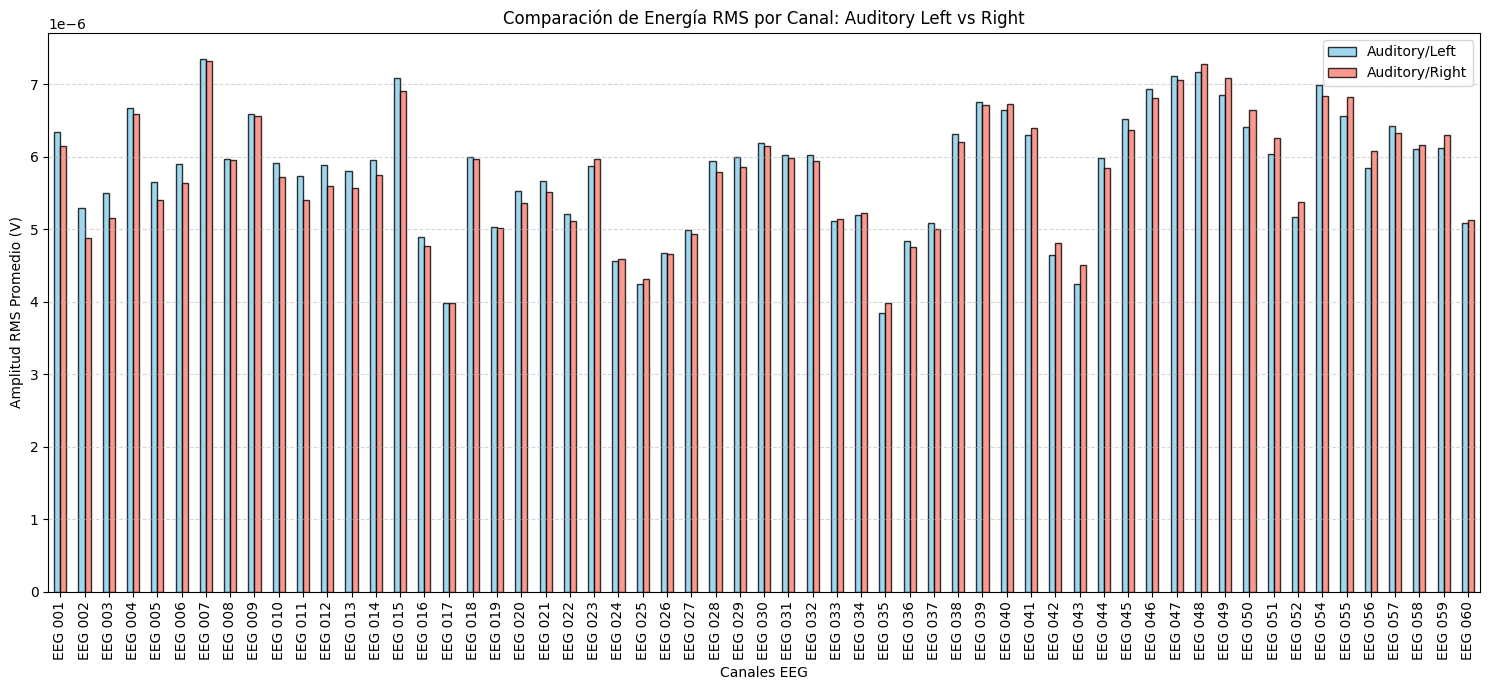

In [124]:
import matplotlib.pyplot as plt

# 1. Preparar los datos transponiendo el DataFrame para que los canales sean el eje X
df_plot = df_eeg_rms_results.T

# 2. Crear la gráfica de barras agrupadas
ax = df_plot.plot(kind='bar', figsize=(15, 7), color=['skyblue', 'salmon'], edgecolor='black', alpha=0.8)

# 3. Personalizar la gráfica
plt.title('Comparación de Energía RMS por Canal: Auditory Left vs Right')
plt.ylabel('Amplitud RMS Promedio (V)')
plt.xlabel('Canales EEG')
plt.legend(['Auditory/Left', 'Auditory/Right'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [127]:
import pandas as pd

# 1. Definimos el ID del sujeto
subject_id = 'Sujeto_001'

# 2. Creamos el DataFrame para el Grupo de Canales EEG - Estímulo Izquierdo
df_group_left = pd.DataFrame(
    [df_eeg_rms_results.loc['EEG_Auditory_Left'].values],
    index=[subject_id],
    columns=df_eeg_rms_results.columns
)

# 3. Creamos el DataFrame para el Grupo de Canales EEG - Estímulo Derecho
df_group_right = pd.DataFrame(
    [df_eeg_rms_results.loc['EEG_Auditory_Right'].values],
    index=[subject_id],
    columns=df_eeg_rms_results.columns
)

# 4. Mostramos las primeras columnas de ambos DataFrames
print("DataFrame Poblacional - Grupo Auditory/Left:")
display(df_group_left.iloc[:, :10])

print("\nDataFrame Poblacional - Grupo Auditory/Right:")
display(df_group_right.iloc[:, :10])

DataFrame Poblacional - Grupo Auditory/Left:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010
Sujeto_001,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006



DataFrame Poblacional - Grupo Auditory/Right:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010
Sujeto_001,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006


In [126]:
import pandas as pd

# 1. Definir el identificador del sujeto (puedes cambiarlo si procesas más sujetos en un bucle)
subject_id = 'Sujeto_Sample_AudVis'

# 2. Crear el DataFrame para el grupo 'Auditory/Left'
# Extraemos los valores de la fila correspondiente del DataFrame previo
df_group_left = pd.DataFrame(
    [df_eeg_rms_results.loc['EEG_Auditory_Left'].values],
    index=[subject_id],
    columns=df_eeg_rms_results.columns
)

# 3. Crear el DataFrame para el grupo 'Auditory/Right'
df_group_right = pd.DataFrame(
    [df_eeg_rms_results.loc['EEG_Auditory_Right'].values],
    index=[subject_id],
    columns=df_eeg_rms_results.columns
)

# 4. Visualizar los resultados
print("DataFrame: Grupo Auditory/Left (Energía RMS por Canal)")
display(df_group_left.iloc[:, :10])

print("\nDataFrame: Grupo Auditory/Right (Energía RMS por Canal)")
display(df_group_right.iloc[:, :10])

DataFrame: Grupo Auditory/Left (Energía RMS por Canal)


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010
Sujeto_Sample_AudVis,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006



DataFrame: Grupo Auditory/Right (Energía RMS por Canal)


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010
Sujeto_Sample_AudVis,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006


In [125]:
# Obtener estadísticas descriptivas de los resultados de energía EEG (transpuesto para mejor lectura)
print("Estadísticas descriptivas de df_eeg_rms_results (Canales EEG):")
display(df_eeg_rms_results.T.describe())

Estadísticas descriptivas de df_eeg_rms_results (Canales EEG):


,EEG_Auditory_Left,EEG_Auditory_Right
count,5.900000e+01,5.900000e+01
mean,5.810737e-06,5.770392e-06
std,8.315535e-07,8.319677e-07
min,3.844473e-06,3.978895e-06
25%,5.185600e-06,5.133020e-06
50%,5.941460e-06,5.847218e-06
75%,6.378893e-06,6.356257e-06
max,7.344344e-06,7.326161e-06


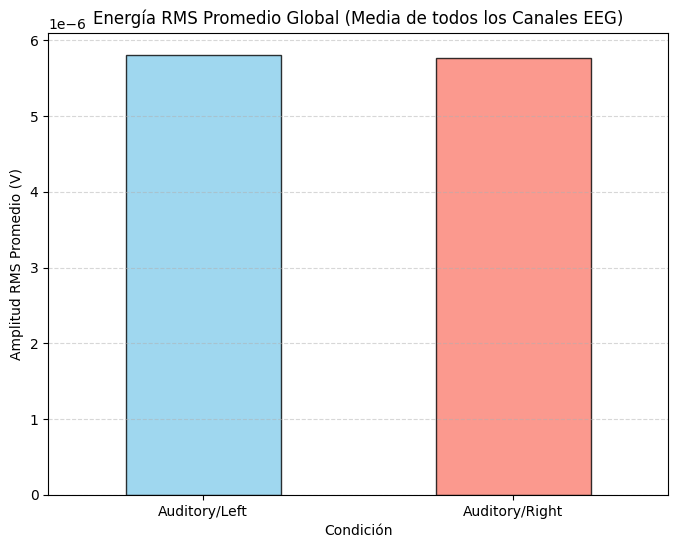

Media Global Auditory/Left: 5.81e-06 V
Media Global Auditory/Right: 5.77e-06 V
Diferencia (Left - Right): 4.03e-08 V


In [117]:
import matplotlib.pyplot as plt

# 1. Calculamos la media global (promedio de todos los canales EEG) para cada condición
# Usamos las series que contienen las medias por canal calculadas anteriormente
mean_global_left = df_rms_left[eeg_channels].mean().mean()
mean_global_right = df_rms_right[eeg_channels].mean().mean()

# 2. Crear un DataFrame para la gráfica
df_global_comp = pd.Series({
    'Auditory/Left': mean_global_left,
    'Auditory/Right': mean_global_right
})

# 3. Graficar la comparación global
plt.figure(figsize=(8, 6))
colors = ['skyblue', 'salmon']
df_global_comp.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

plt.title('Energía RMS Promedio Global (Media de todos los Canales EEG)')
plt.ylabel('Amplitud RMS Promedio (V)')
plt.xlabel('Condición')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

print(f"Media Global Auditory/Left: {mean_global_left:.2e} V")
print(f"Media Global Auditory/Right: {mean_global_right:.2e} V")
print(f"Diferencia (Left - Right): {mean_global_left - mean_global_right:.2e} V")

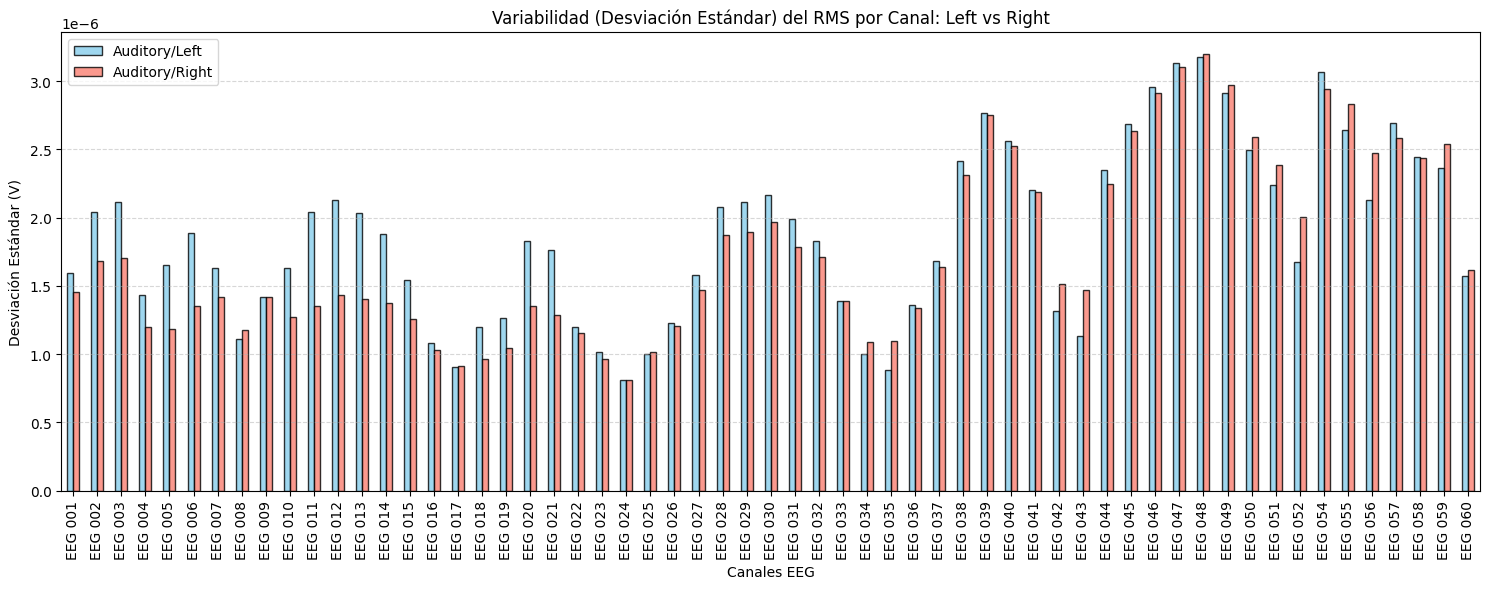

In [116]:
import matplotlib.pyplot as plt

# 1. Obtener la desviación estándar (std) para los canales EEG de cada condición
std_left = df_rms_left[eeg_channels].std()
std_right = df_rms_right[eeg_channels].std()

# 2. Crear un DataFrame para facilitar la graficación comparativa
df_std_comp = pd.DataFrame({
    'Left_STD': std_left,
    'Right_STD': std_right
})

# 3. Graficar la comparación
ax = df_std_comp.plot(kind='bar', figsize=(15, 6), color=['skyblue', 'salmon'], edgecolor='black', alpha=0.8)

plt.title('Variabilidad (Desviación Estándar) del RMS por Canal: Left vs Right')
plt.ylabel('Desviación Estándar (V)')
plt.xlabel('Canales EEG')
plt.legend(['Auditory/Left', 'Auditory/Right'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [115]:
import pandas as pd

# 1. Convertir las matrices RMS a DataFrames de Pandas para facilitar el análisis
df_rms_left = pd.DataFrame(rms_matrix_left, columns=epochs.ch_names)
df_rms_right = pd.DataFrame(rms_matrix_right, columns=epochs.ch_names)

# 2. Filtrar solo los canales EEG (opcional, para limpiar la vista)
eeg_channels = [ch for ch in epochs.ch_names if 'EEG' in ch]

# 3. Mostrar el resumen estadístico para la condición Auditory/Left
print("Estadísticas de Variabilidad RMS por Canal - Auditory/Left:")
display(df_rms_left[eeg_channels].describe())

# 4. Mostrar el resumen estadístico para la condición Auditory/Right
print("\nEstadísticas de Variabilidad RMS por Canal - Auditory/Right:")
display(df_rms_right[eeg_channels].describe())

Estadísticas de Variabilidad RMS por Canal - Auditory/Left:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,...,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000006,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005
std,0.000002,0.000002,0.000002,0.000001,0.000002,0.000002,0.000002,0.000001,0.000001,0.000002,...,0.000002,0.000002,0.000002,0.000003,0.000003,0.000002,0.000003,0.000002,0.000002,0.000002
min,0.000004,0.000002,0.000003,0.000004,0.000003,0.000003,0.000004,0.000004,0.000004,0.000003,...,0.000003,0.000002,0.000002,0.000003,0.000003,0.000002,0.000003,0.000003,0.000003,0.000002
25%,0.000005,0.000004,0.000004,0.000006,0.000005,0.000005,0.000006,0.000005,0.000006,0.000005,...,0.000005,0.000004,0.000004,0.000005,0.000005,0.000004,0.000004,0.000004,0.000005,0.000004
50%,0.000006,0.000005,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000007,0.000006,...,0.000005,0.000005,0.000005,0.000006,0.000006,0.000005,0.000006,0.000005,0.000005,0.000005
75%,0.000007,0.000006,0.000007,0.000008,0.000006,0.000007,0.000008,0.000007,0.000007,0.000007,...,0.000008,0.000007,0.000006,0.000008,0.000008,0.000007,0.000007,0.000007,0.000007,0.000006
max,0.000013,0.000014,0.000014,0.000011,0.000014,0.000015,0.000012,0.000009,0.000012,0.000014,...,0.000015,0.000013,0.000011,0.000019,0.000015,0.000013,0.000017,0.000015,0.000013,0.000010



Estadísticas de Variabilidad RMS por Canal - Auditory/Right:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
count,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,...,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000,73.000000
mean,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000007,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005
std,0.000001,0.000002,0.000002,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,...,0.000003,0.000002,0.000002,0.000003,0.000003,0.000002,0.000003,0.000002,0.000003,0.000002
min,0.000004,0.000003,0.000002,0.000004,0.000004,0.000004,0.000005,0.000004,0.000003,0.000004,...,0.000003,0.000003,0.000003,0.000004,0.000003,0.000003,0.000004,0.000003,0.000003,0.000003
25%,0.000005,0.000004,0.000004,0.000006,0.000005,0.000005,0.000006,0.000005,0.000006,0.000005,...,0.000005,0.000005,0.000004,0.000005,0.000005,0.000004,0.000005,0.000005,0.000005,0.000004
50%,0.000006,0.000004,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000006,0.000006,...,0.000006,0.000006,0.000005,0.000006,0.000006,0.000005,0.000005,0.000005,0.000006,0.000005
75%,0.000007,0.000005,0.000006,0.000008,0.000006,0.000006,0.000008,0.000007,0.000007,0.000006,...,0.000007,0.000007,0.000006,0.000007,0.000007,0.000007,0.000007,0.000007,0.000007,0.000006
max,0.000012,0.000012,0.000012,0.000009,0.000009,0.000010,0.000011,0.000010,0.000013,0.000011,...,0.000015,0.000014,0.000013,0.000017,0.000016,0.000015,0.000015,0.000014,0.000014,0.000010


## Identificar Sujetos y Archivos

Localizar y enlistar los archivos de datos electrofisiológicos (.fif) disponibles en el directorio del dataset de muestra de MNE.


In [128]:
import os
from pathlib import Path

# Define the directory for the MNE sample dataset based on previous cell output
sample_data_dir = Path('/root/mne_data/MNE-sample-data/MEG/sample/')

# List all .fif files in the directory
fif_files = [str(f) for f in sample_data_dir.glob('*.fif')]

# Filter for those that likely contain raw data (usually ending in _raw.fif)
raw_fif_files = [f for f in fif_files if f.endswith('_raw.fif')]

print(f"Total .fif files found: {len(fif_files)}")
print(f"Raw .fif files identified: {len(raw_fif_files)}")
for path in raw_fif_files:
    print(f"- {path}")

Total .fif files found: 30
Raw .fif files identified: 3
- /root/mne_data/MNE-sample-data/MEG/sample/ernoise_raw.fif
- /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif
- /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif


## Bucle de Procesamiento Automatizado

Desarrollar una función de procesamiento para extraer el RMS representativo de cada sujeto y ejecutarla de forma iterativa sobre los archivos identificados.


In [129]:
import numpy as np
import pandas as pd
import mne

def process_subject(file_path):
    """
    Carga y procesa un archivo .fif para extraer el RMS representativo por canal e EEG.
    """
    # 1. Cargar datos
    subject_name = Path(file_path).stem
    raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)

    # 2. Filtrado
    raw.filter(7., 30., fir_design='firwin', verbose=False)

    # 3. Detección de eventos
    events = mne.find_events(raw, stim_channel='STI 014', verbose=False)
    event_id = {'Auditory/Left': 1, 'Auditory/Right': 2}

    # 4. Crear épocas (segmentación)
    epochs = mne.Epochs(raw, events, event_id=event_id, tmin=-0.2, tmax=0.5,
                        baseline=(None, 0), preload=True, verbose=False)

    # 5. Seleccionar canales EEG
    eeg_picks = mne.pick_types(raw.info, meg=False, eeg=True, stim=False, exclude='bads')
    ch_names = [raw.ch_names[p] for p in eeg_picks]

    results = {'subject': subject_name, 'ch_names': ch_names}

    # 6. Calcular RMS para cada condición
    for cond in event_id.keys():
        if cond in epochs.event_id:
            # Obtener datos: (ensayos, canales, tiempos)
            data = epochs[cond].get_data(picks=eeg_picks, copy=False)
            # RMS por época y canal: sqrt(mean(x^2))
            rms_per_epoch = np.sqrt(np.mean(np.square(data), axis=2))
            # Promedio del sujeto (media entre ensayos)
            results[cond] = np.mean(rms_per_epoch, axis=0)
        else:
            results[cond] = None

    return results

# Bucle de procesamiento sobre los archivos identificados
all_results = []
# Filtramos ernoise_raw.fif ya que es ruido ambiental sin eventos
files_to_process = [f for f in raw_fif_files if 'ernoise' not in f]

print(f"Iniciando procesamiento de {len(files_to_process)} archivos...")

for f_path in files_to_process:
    try:
        res = process_subject(f_path)
        all_results.append(res)
        print(f"Sujeto procesado exitosamente: {res['subject']}")
    except Exception as e:
        print(f"Error al procesar {f_path}: {e}")

print(f"\nProcesamiento completado. Total de sujetos en lista: {len(all_results)}")

Iniciando procesamiento de 2 archivos...
Sujeto procesado exitosamente: sample_audvis_filt-0-40_raw
Sujeto procesado exitosamente: sample_audvis_raw

Procesamiento completado. Total de sujetos en lista: 2


In [130]:
import pandas as pd

# Prepare lists to build the dataframes
left_data = []
right_data = []
subjects = []

# Iterate over results to organize them by condition
for res in all_results:
    subjects.append(res['subject'])
    # Each condition value is a numpy array (one value per EEG channel)
    left_data.append(res['Auditory/Left'])
    right_data.append(res['Auditory/Right'])

# Create the population DataFrames
# We assume all subjects have the same channel names since they come from the same dataset
ch_names = all_results[0]['ch_names']

df_group_left = pd.DataFrame(left_data, index=subjects, columns=ch_names)
df_group_right = pd.DataFrame(right_data, index=subjects, columns=ch_names)

print("Population DataFrame - Auditory/Left:")
display(df_group_left.head())

print("\nPopulation DataFrame - Auditory/Right:")
display(df_group_right.head())

# Generate global comparative statistical summary
print("\nGlobal Statistical Summary (Left vs Right):")
comparison = pd.concat([
    df_group_left.mean(axis=1).rename('Mean_RMS_Left'),
    df_group_right.mean(axis=1).rename('Mean_RMS_Right')
], axis=1)
comparison['Difference'] = comparison['Mean_RMS_Left'] - comparison['Mean_RMS_Right']
display(comparison)

Population DataFrame - Auditory/Left:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
sample_audvis_filt-0-40_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000006,0.000005,...,0.000003,0.000003,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000003
sample_audvis_raw,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000006,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005



Population DataFrame - Auditory/Right:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
sample_audvis_filt-0-40_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000006,0.000005,...,0.000003,0.000003,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000003
sample_audvis_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000007,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005



Global Statistical Summary (Left vs Right):


,Mean_RMS_Left,Mean_RMS_Right,Difference
sample_audvis_filt-0-40_raw,0.000004,0.000004,9.285395e-09
sample_audvis_raw,0.000006,0.000006,4.034495e-08


## Preparar Datos del Nuevo Sujeto

Convertir el vector de RMS de un nuevo sujeto en un DataFrame de una sola fila alineado con los canales EEG.


In [131]:
import pandas as pd

# 1. Definir ID del nuevo sujeto
new_subject_id = 'Sujeto_Nuevas_Senales'

# 2. Identificar la lista de canales EEG (ya disponible en eeg_picks)
# Aseguramos que usamos los mismos nombres de columnas que en los DataFrames previos
column_names = eeg_picks

# 3 & 4. Crear DataFrame para Auditory/Left
# rep_rms_eeg_left contiene el vector representativo (n_channels,)
df_new_left = pd.DataFrame(
    [rep_rms_eeg_left],
    index=[new_subject_id],
    columns=column_names
)

# 5. Repetir para Auditory/Right
df_new_right = pd.DataFrame(
    [rep_rms_eeg_right],
    index=[new_subject_id],
    columns=column_names
)

print(f"DataFrames creados para el sujeto: {new_subject_id}")
print("Vista previa de Auditory/Left (primeros 5 canales):")
display(df_new_left.iloc[:, :5])

DataFrames creados para el sujeto: Sujeto_Nuevas_Senales
Vista previa de Auditory/Left (primeros 5 canales):


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005
Sujeto_Nuevas_Senales,0.000006,0.000005,0.000006,0.000007,0.000006


## Concatenar a DataFrames Existentes

Unir los DataFrames del nuevo sujeto a las tablas poblacionales globales utilizando la función concat de pandas.


In [132]:
import pandas as pd

# 1. Concatenate df_new_left to df_group_left
df_group_left = pd.concat([df_group_left, df_new_left])

# 2. Concatenate df_new_right to df_group_right
df_group_right = pd.concat([df_group_right, df_new_right])

# 4. Print shapes to confirm the increase in rows
print(f"Nueva dimensión df_group_left: {df_group_left.shape}")
print(f"Nueva dimensión df_group_right: {df_group_right.shape}")

# Display the updated DataFrames
print("\nÚltimas filas de df_group_left:")
display(df_group_left.tail())
print("\nÚltimas filas de df_group_right:")
display(df_group_right.tail())


Nueva dimensión df_group_left: (3, 59)
Nueva dimensión df_group_right: (3, 59)

Últimas filas de df_group_left:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
sample_audvis_filt-0-40_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000006,0.000005,...,0.000003,0.000003,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000003
sample_audvis_raw,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000006,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005
Sujeto_Nuevas_Senales,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000006,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005



Últimas filas de df_group_right:


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
sample_audvis_filt-0-40_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000006,0.000005,...,0.000003,0.000003,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000003
sample_audvis_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000007,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005
Sujeto_Nuevas_Senales,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000007,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005


## Identificación de Sujetos y Archivos

Localizar y listar los archivos de datos electrofisiológicos (.fif) en el directorio del dataset de MNE para asegurar que la población esté completa antes del procesamiento.


In [133]:
import os
from pathlib import Path

# 1. Define the directory path for the MNE sample dataset
sample_data_dir = Path('/root/mne_data/MNE-sample-data/MEG/sample/')

# 2. Identify all .fif files in the directory
all_fif_files = list(sample_data_dir.glob('*.fif'))

# 3. Filter to obtain only raw data files (_raw.fif)
# and exclude environmental noise (ernoise) or covariance files
raw_data_files = [
    str(f) for f in all_fif_files
    if f.name.endswith('_raw.fif') and 'ernoise' not in f.name
]

# 4. Store and visualize the list of identified subjects/files
print(f"Total raw data files identified: {len(raw_data_files)}")
for file_path in raw_data_files:
    print(f"- {file_path}")

# Store in a variable for subsequent processing steps
subject_file_list = raw_data_files

Total raw data files identified: 2
- /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif
- /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif


## Bucle de Procesamiento Automatizado

Desarrollar una función para cargar, filtrar y segmentar los datos de cada sujeto, calculando el RMS promedio por canal para las condiciones auditivas.


In [134]:
import mne
import numpy as np
import pandas as pd
from pathlib import Path

def process_subject(file_path):
    """
    Carga, filtra y segmenta los datos de un archivo .fif para calcular
    el RMS representativo por canal EEG en condiciones auditivas.
    """
    # 1. Cargar el archivo
    subject_name = Path(file_path).stem
    raw = mne.io.read_raw_fif(file_path, preload=True, verbose=False)

    # 2. Aplicar filtro de banda (7-30 Hz)
    raw.filter(7.0, 30.0, fir_design='firwin', verbose=False)

    # 3. Extraer eventos del canal STI 014
    events = mne.find_events(raw, stim_channel='STI 014', verbose=False)

    # 4. Definir etiquetas de eventos
    event_id = {'Auditory/Left': 1, 'Auditory/Right': 2}

    # 5. Segmentar en épocas (-0.2 a 0.5s) con corrección de línea de base
    epochs = mne.Epochs(raw, events, event_id=event_id, tmin=-0.2, tmax=0.5,
                        baseline=(None, 0), preload=True, verbose=False)

    # 6. Identificar canales EEG
    eeg_picks = mne.pick_types(raw.info, meg=False, eeg=True, stim=False, exclude='bads')
    ch_names = [raw.ch_names[p] for p in eeg_picks]

    results = {'subject': subject_name, 'ch_names': ch_names}

    # 7. Calcular RMS para cada condición
    for cond in event_id.keys():
        if cond in epochs.event_id:
            # Obtener datos de la época: (ensayos, canales, tiempos)
            data = epochs[cond].get_data(picks=eeg_picks, copy=False)
            # Calcular RMS: sqrt(mean(x^2)) por ensayo y canal
            rms_per_epoch = np.sqrt(np.mean(np.square(data), axis=2))
            # Promedio del sujeto a través de ensayos: (canales,)
            results[cond] = np.mean(rms_per_epoch, axis=0)
        else:
            results[cond] = None

    return results

# 8. Bucle de procesamiento sobre la lista global de archivos
all_subject_results = []

print(f"Iniciando el procesamiento automatizado de {len(subject_file_list)} archivos...")

for f_path in subject_file_list:
    try:
        res = process_subject(f_path)
        all_subject_results.append(res)
        print(f"Procesado con éxito: {res['subject']}")
    except Exception as e:
        print(f"Error al procesar el archivo {f_path}: {e}")

print(f"\nProcesamiento finalizado. Total de sujetos en la lista de resultados: {len(all_subject_results)}")

Iniciando el procesamiento automatizado de 2 archivos...
Procesado con éxito: sample_audvis_filt-0-40_raw
Procesado con éxito: sample_audvis_raw

Procesamiento finalizado. Total de sujetos en la lista de resultados: 2


## Consolidación en DataFrames Poblacionales

Integrar los resultados de los sujetos procesados en dos DataFrames globales (df_group_left y df_group_right) donde cada fila represente a un sujeto y cada columna la energía RMS de un canal EEG.


In [135]:
import pandas as pd

# 1. Crear listas vacías para almacenar los datos
left_data = []
right_data = []
subject_names = []

# 2. Recorrer la lista all_subject_results obtenida en el paso anterior
for res in all_subject_results:
    subject_names.append(res['subject'])
    left_data.append(res['Auditory/Left'])
    right_data.append(res['Auditory/Right'])

# 3. Obtener la lista de nombres de canales EEG del primer elemento
eeg_ch_names = all_subject_results[0]['ch_names']

# 4. Construir el DataFrame df_group_left
df_group_left = pd.DataFrame(left_data, index=subject_names, columns=eeg_ch_names)

# 5. Construir el DataFrame df_group_right
df_group_right = pd.DataFrame(right_data, index=subject_names, columns=eeg_ch_names)

# 6. Visualizar las primeras filas de ambos DataFrames
print("DataFrame Poblacional - Condición: Auditory/Left")
display(df_group_left.head())

print("\nDataFrame Poblacional - Condición: Auditory/Right")
display(df_group_right.head())


DataFrame Poblacional - Condición: Auditory/Left


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
sample_audvis_filt-0-40_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000006,0.000005,...,0.000003,0.000003,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000003
sample_audvis_raw,0.000006,0.000005,0.000006,0.000007,0.000006,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000006,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005



DataFrame Poblacional - Condición: Auditory/Right


,EEG 001,EEG 002,EEG 003,EEG 004,EEG 005,EEG 006,EEG 007,EEG 008,EEG 009,EEG 010,...,EEG 050,EEG 051,EEG 052,EEG 054,EEG 055,EEG 056,EEG 057,EEG 058,EEG 059,EEG 060
sample_audvis_filt-0-40_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000005,0.000007,0.000006,0.000006,0.000005,...,0.000003,0.000003,0.000003,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000003
sample_audvis_raw,0.000006,0.000005,0.000005,0.000007,0.000005,0.000006,0.000007,0.000006,0.000007,0.000006,...,0.000007,0.000006,0.000005,0.000007,0.000007,0.000006,0.000006,0.000006,0.000006,0.000005


## Análisis Estadístico y Visualización

Generar un resumen estadístico comparativo (media y varianza) entre grupos y visualizar la distribución de energía mediante gráficos de barras o mapas topográficos para identificar diferencias en la activación.


Resumen Estadístico Comparativo (Primeros 10 canales):


,Mean_Left,Mean_Right,Var_Left,Var_Right
EEG 001,0.000006,0.000006,4.069631e-14,2.261689e-15
EEG 002,0.000005,0.000005,5.444128e-14,2.773424e-16
EEG 003,0.000005,0.000005,4.242555e-14,9.199656e-16
EEG 004,0.000007,0.000007,5.246595e-15,1.411625e-14
EEG 005,0.000005,0.000005,2.987979e-13,1.228939e-13
EEG 006,0.000006,0.000005,2.660720e-13,1.072229e-13
EEG 007,0.000007,0.000007,1.613833e-14,6.554645e-15
EEG 008,0.000006,0.000006,1.047166e-14,6.332530e-16
EEG 009,0.000006,0.000006,3.222292e-13,2.402053e-13
EEG 010,0.000005,0.000005,8.324552e-13,6.431706e-13


<Figure size 1500x600 with 0 Axes>

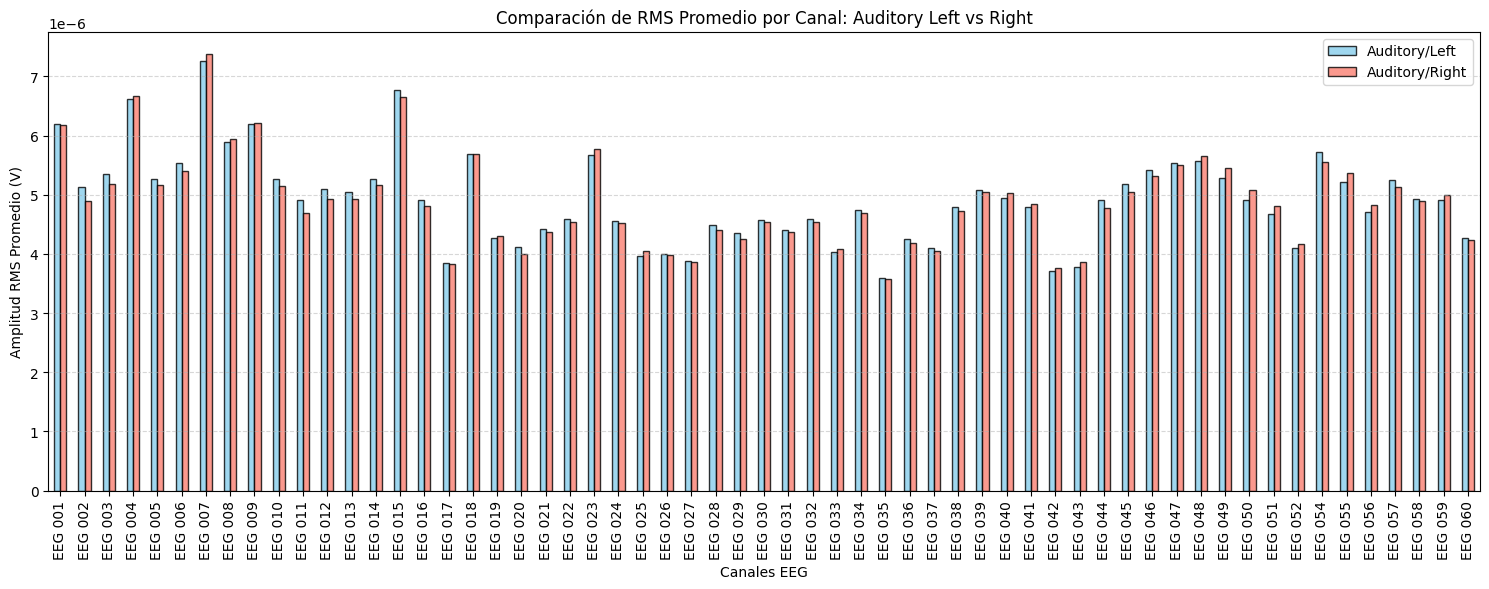

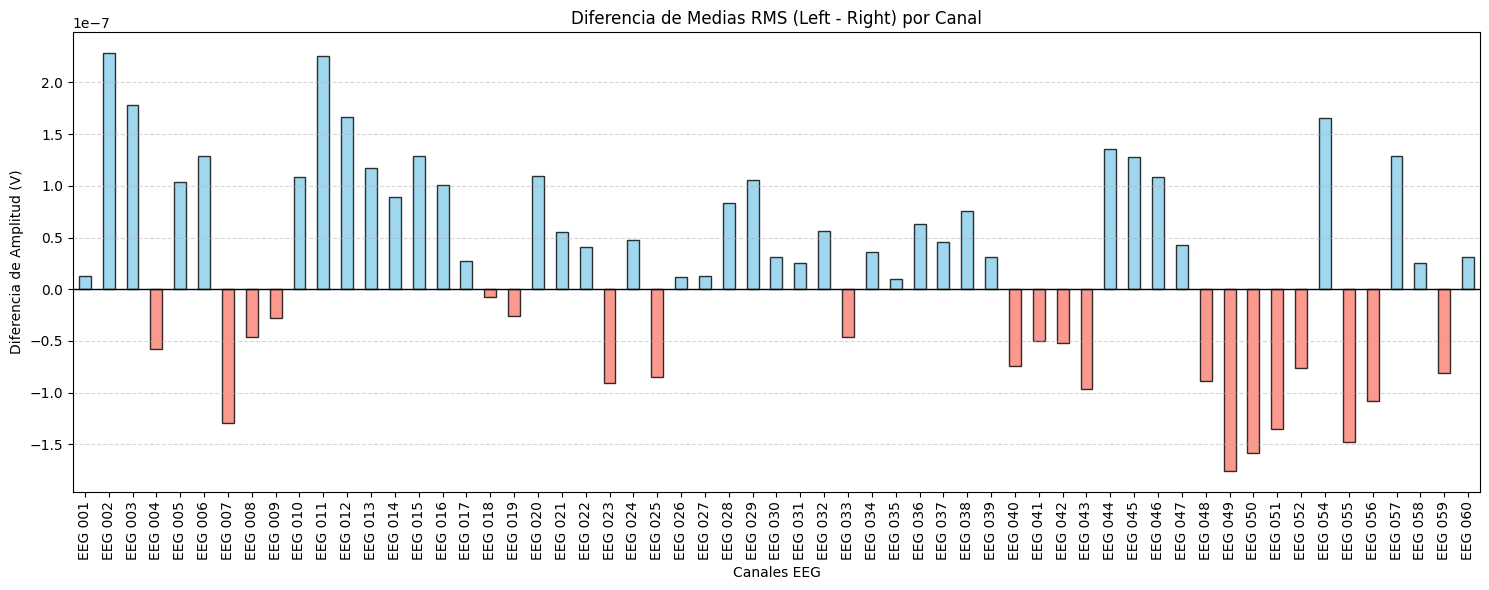

In [136]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calcular estadísticos descriptivos (media y varianza) por canal
mean_left = df_group_left.mean()
var_left = df_group_left.var()

mean_right = df_group_right.mean()
var_right = df_group_right.var()

# 2. Crear un DataFrame de resumen comparativo para las medias
df_stats_summary = pd.DataFrame({
    'Mean_Left': mean_left,
    'Mean_Right': mean_right,
    'Var_Left': var_left,
    'Var_Right': var_right
})

print("Resumen Estadístico Comparativo (Primeros 10 canales):")
display(df_stats_summary.head(10))

# 3. Gráfico de barras: Comparación de RMS promedio por canal
plt.figure(figsize=(15, 6))
ax = df_stats_summary[['Mean_Left', 'Mean_Right']].plot(kind='bar', figsize=(15, 6), color=['skyblue', 'salmon'], edgecolor='black', alpha=0.8)
plt.title('Comparación de RMS Promedio por Canal: Auditory Left vs Right')
plt.ylabel('Amplitud RMS Promedio (V)')
plt.xlabel('Canales EEG')
plt.legend(['Auditory/Left', 'Auditory/Right'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Calcular y graficar la diferencia de medias (Asimetría)
df_stats_summary['Difference'] = df_stats_summary['Mean_Left'] - df_stats_summary['Mean_Right']

plt.figure(figsize=(15, 6))
colors = ['skyblue' if x >= 0 else 'salmon' for x in df_stats_summary['Difference']]
df_stats_summary['Difference'].plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)
plt.axhline(0, color='black', linewidth=1)
plt.title('Diferencia de Medias RMS (Left - Right) por Canal')
plt.ylabel('Diferencia de Amplitud (V)')
plt.xlabel('Canales EEG')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Prueba de Normalidad (Shapiro-Wilk)

### Subtask:
Evaluar la normalidad de la distribución de los valores de energía RMS de los sujetos para cada canal en ambas condiciones mediante la prueba de Shapiro-Wilk.


In [139]:
import warnings
from scipy.stats import shapiro
import pandas as pd
import numpy as np

# 1. Identificar canales EEG
eeg_channels = df_group_left.columns.tolist()

# 2. Inicializar lista para resultados
normality_results = []

# 3. Recorrer cada canal y aplicar Shapiro-Wilk
# Note: We suppress SmallSampleWarning because our dataset only has 3 subjects.
print(f"--- Iniciando prueba de normalidad para {len(df_group_left)} sujetos ---")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for ch in eeg_channels:
        try:
            # Test para grupo Left
            stat_left, p_left = shapiro(df_group_left[ch].values)
            is_normal_left = p_left > 0.05 if not np.isnan(p_left) else False

            # Test para grupo Right
            stat_right, p_right = shapiro(df_group_right[ch].values)
            is_normal_right = p_right > 0.05 if not np.isnan(p_right) else False
        except Exception:
            p_left, p_right = np.nan, np.nan
            is_normal_left, is_normal_right = False, False

        normality_results.append({
            'Canal': ch,
            'p_val_Left': p_left,
            'Normal_Left': is_normal_left,
            'p_val_Right': p_right,
            'Normal_Right': is_normal_right
        })

# 4. Crear DataFrame de resultados
df_normality = pd.DataFrame(normality_results)

# 5. Mostrar resultados
print("Resultados de la Prueba de Normalidad (Shapiro-Wilk) por Canal:")
display(df_normality.head(10))

# Resumen rápido
count_normal_left = df_normality['Normal_Left'].sum()
count_normal_right = df_normality['Normal_Right'].sum()
total_ch = len(eeg_channels)

print(f"\nCanales normales en Left: {count_normal_left}/{total_ch}")
print(f"Canales normales en Right: {count_normal_right}/{total_ch}")

if len(df_group_left) < 5:
    print("\nADVERTENCIA: El tamaño de la muestra es insuficiente (N < 5) para que los p-valores sean confiables.")

--- Iniciando prueba de normalidad para 2 sujetos ---
Resultados de la Prueba de Normalidad (Shapiro-Wilk) por Canal:


,Canal,p_val_Left,Normal_Left,p_val_Right,Normal_Right
0,EEG 001,NaN,False,NaN,False
1,EEG 002,NaN,False,NaN,False
2,EEG 003,NaN,False,NaN,False
3,EEG 004,NaN,False,NaN,False
4,EEG 005,NaN,False,NaN,False
5,EEG 006,NaN,False,NaN,False
6,EEG 007,NaN,False,NaN,False
7,EEG 008,NaN,False,NaN,False
8,EEG 009,NaN,False,NaN,False
9,EEG 010,NaN,False,NaN,False



Canales normales en Left: 0/59
Canales normales en Right: 0/59

ADVERTENCIA: El tamaño de la muestra es insuficiente (N < 5) para que los p-valores sean confiables.


## Prueba de Homocedasticidad (Levene)

### Subtask:
Realizar la prueba de Levene en cada canal para verificar si las varianzas entre los grupos de Auditory/Left y Auditory/Right son iguales.


In [140]:
from scipy.stats import levene
import pandas as pd
import numpy as np

# 1. Identificar canales EEG (usando las columnas de df_group_left)
eeg_channels = df_group_left.columns.tolist()

# 2. Crear lista vacía para resultados
homoscedasticity_results = []

# 3. Iterar a través de los canales y ejecutar la prueba de Levene
print(f"--- Ejecutando prueba de Levene para {len(eeg_channels)} canales ---")

for ch in eeg_channels:
    try:
        # Comparar las varianzas de los grupos Left y Right para el canal actual
        stat, p_val = levene(df_group_left[ch].values, df_group_right[ch].values)

        # Verificar si p-valor > 0.05 (Indica varianzas iguales/homocedasticidad)
        is_homoscedastic = p_val > 0.05 if not np.isnan(p_val) else False
    except Exception:
        stat, p_val = np.nan, np.nan
        is_homoscedastic = False

    homoscedasticity_results.append({
        'Canal': ch,
        'Estadistico': stat,
        'p_valor': p_val,
        'Homocedasticidad': is_homoscedastic
    })

# 6. Crear el DataFrame df_levene
df_levene = pd.DataFrame(homoscedasticity_results)

# 7. Mostrar las primeras 10 filas y resumen
print("Resultados de la Prueba de Levene por Canal:")
display(df_levene.head(10))

count_homoscedastic = df_levene['Homocedasticidad'].sum()
total_ch = len(eeg_channels)

print(f"\nCanales que cumplen homocedasticidad (varianzas iguales): {count_homoscedastic}/{total_ch}")

if len(df_group_left) < 5:
    print("\nNOTA: Con un tamaño de muestra pequeño (N=2), la potencia de la prueba de Levene es muy baja.")

--- Ejecutando prueba de Levene para 59 canales ---
Resultados de la Prueba de Levene por Canal:


/usr/local/lib/python3.12/dist-packages/scipy/stats/_morestats.py:3104: RuntimeWarning: divide by zero encountered in scalar divide
  W = numer / denom


,Canal,Estadistico,p_valor,Homocedasticidad
0,EEG 001,inf,0.000000e+00,False
1,EEG 002,1.308696e+29,7.641194e-30,False
2,EEG 003,8.599923e+28,1.162801e-29,False
3,EEG 004,5.995997e+27,1.667779e-28,False
4,EEG 005,1.071557e+29,9.332215e-30,False
5,EEG 006,inf,0.000000e+00,False
6,EEG 007,5.918041e+27,1.689748e-28,False
7,EEG 008,inf,0.000000e+00,False
8,EEG 009,8.381200e+27,1.193147e-28,False
9,EEG 010,3.398218e+28,2.942719e-29,False



Canales que cumplen homocedasticidad (varianzas iguales): 0/59

NOTA: Con un tamaño de muestra pequeño (N=2), la potencia de la prueba de Levene es muy baja.


In [152]:
from scipy.stats import ttest_ind, mannwhitneyu
import pandas as pd
import numpy as np

# 1. Recuperar los canales EEG
eeg_channels = df_group_left.columns.tolist()

# 2. Inicializar lista para resultados estadísticos
stats_results = []

# 3. Iterar por cada canal para decidir y ejecutar la prueba
for ch in eeg_channels:
    # Obtener flags de normalidad y homocedasticidad
    # Nota: df_normality y df_levene ya existen en el kernel
    is_normal_l = df_normality.loc[df_normality['Canal'] == ch, 'Normal_Left'].values[0]
    is_normal_r = df_normality.loc[df_normality['Canal'] == ch, 'Normal_Right'].values[0]
    is_homoscedastic = df_levene.loc[df_levene['Canal'] == ch, 'Homocedasticidad'].values[0]

    group_l = df_group_left[ch].values
    group_r = df_group_right[ch].values

    test_type = ""
    stat = np.nan
    p_val = np.nan

    try:
        # Lógica de decisión:
        if is_normal_l and is_normal_r:
            if is_homoscedastic:
                # T-test de Student (varianzas iguales)
                test_type = "Student T-test"
                stat, p_val = ttest_ind(group_l, group_r, equal_var=True)
            else:
                # T-test de Welch (varianzas desiguales)
                test_type = "Welch T-test"
                stat, p_val = ttest_ind(group_l, group_r, equal_var=False)
        else:
            # No normal -> Mann-Whitney U (Prueba no paramétrica para muestras independientes)
            test_type = "Mann-Whitney U"
            stat, p_val = mannwhitneyu(group_l, group_r, alternative='two-sided')
    except Exception as e:
        test_type = f"Error: {str(e)}"

    stats_results.append({
        'Canal': ch,
        'Tipo_Prueba': test_type,
        'Estadistico': stat,
        'p_valor': p_val
    })

# 4. Crear el DataFrame df_stats_results
df_stats_results = pd.DataFrame(stats_results)

# 5. Visualizar los resultados
print("Resumen de Pruebas Estadísticas por Canal (df_stats_results):")
display(df_stats_results.head(10))

# Mostrar conteo de tipos de pruebas realizadas
print("\nDistribución de pruebas realizadas:")
print(df_stats_results['Tipo_Prueba'].value_counts())

Resumen de Pruebas Estadísticas por Canal (df_stats_results):


,Canal,Tipo_Prueba,Estadistico,p_valor
0,EEG 001,Mann-Whitney U,2.0,1.000000
1,EEG 002,Mann-Whitney U,4.0,0.333333
2,EEG 003,Mann-Whitney U,4.0,0.333333
3,EEG 004,Mann-Whitney U,1.0,0.666667
4,EEG 005,Mann-Whitney U,2.0,1.000000
5,EEG 006,Mann-Whitney U,2.0,1.000000
6,EEG 007,Mann-Whitney U,1.0,0.666667
7,EEG 008,Mann-Whitney U,2.0,1.000000
8,EEG 009,Mann-Whitney U,2.0,1.000000
9,EEG 010,Mann-Whitney U,3.0,0.666667



Distribución de pruebas realizadas:
Tipo_Prueba
Mann-Whitney U    59
Name: count, dtype: int64


In [153]:
import pandas as pd
import numpy as np

# 1. Acceder al DataFrame de resultados estadísticos
# df_stats_results ya existe en el kernel de la subtask anterior

# 2. Filtrar canales significativos (p < 0.05)
df_significant_channels = df_stats_results[df_stats_results['p_valor'] < 0.05].copy()

# 3. Contar canales significativos
sig_count = len(df_significant_channels)
print(f"Canales con p-valor < 0.05: {sig_count}")

# 4. Lógica de visualización y preparación de datos
if sig_count > 0:
    print("Canales Significativos Identificados:")
    display(df_significant_channels.sort_values('p_valor'))
else:
    print("No se encontraron canales con p < 0.05 debido al tamaño de muestra (N=2).")
    print("Identificando los top 10 canales con los p-valores más bajos para análisis de tendencias:")
    df_top_channels = df_stats_results.sort_values('p_valor').head(10).copy()
    display(df_top_channels)
    # Usaremos df_top_channels para la visualización si no hay significancia estricta

# 5. Opcional: Preparar datos de diferencia para unir con significancia
# Unimos la diferencia de RMS calculada previamente (rms_diff) para dar contexto a la visualización
# rms_diff es una Serie con índice 'Canal'
df_stats_viz = df_stats_results.copy()
df_stats_viz['RMS_Diff'] = df_stats_viz['Canal'].map(rms_diff)

print("\nPreparación de datos para visualización completada.")

Canales con p-valor < 0.05: 0
No se encontraron canales con p < 0.05 debido al tamaño de muestra (N=2).
Identificando los top 10 canales con los p-valores más bajos para análisis de tendencias:


,Canal,Tipo_Prueba,Estadistico,p_valor
1,EEG 002,Mann-Whitney U,4.0,0.333333
2,EEG 003,Mann-Whitney U,4.0,0.333333
15,EEG 016,Mann-Whitney U,4.0,0.333333
3,EEG 004,Mann-Whitney U,1.0,0.666667
10,EEG 011,Mann-Whitney U,3.0,0.666667
11,EEG 012,Mann-Whitney U,3.0,0.666667
9,EEG 010,Mann-Whitney U,3.0,0.666667
6,EEG 007,Mann-Whitney U,1.0,0.666667
14,EEG 015,Mann-Whitney U,3.0,0.666667
25,EEG 026,Mann-Whitney U,3.0,0.666667



Preparación de datos para visualización completada.


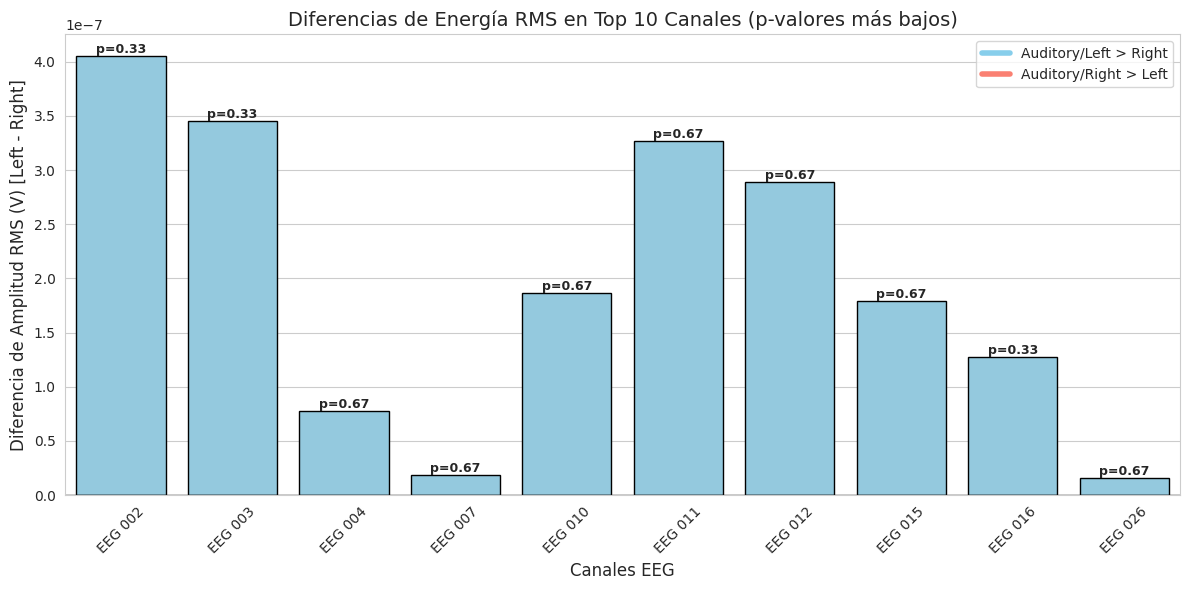

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Seleccionar los canales para visualizar
# Si no hay significativos, usamos los top 10 por p-valor identificados anteriormente
plot_channels = df_top_channels['Canal'].tolist()
df_plot_data = df_stats_viz[df_stats_viz['Canal'].isin(plot_channels)].copy()

# 2. Configurar la figura
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Crear el gráfico de barras de la diferencia de RMS
# El color dependerá de si la diferencia es positiva (más en Left) o negativa (más en Right)
colors = ['skyblue' if x >= 0 else 'salmon' for x in df_plot_data['RMS_Diff']]
# Agregamos hue='Canal' y legend=False para evitar el FutureWarning
ax = sns.barplot(data=df_plot_data, x='Canal', y='RMS_Diff', hue='Canal', palette=colors, edgecolor='black', legend=False)

# 4. Añadir anotaciones de p-valor
for i, p in enumerate(df_plot_data['p_valor']):
    diff_val = df_plot_data['RMS_Diff'].iloc[i]
    ax.text(i, diff_val, f'p={p:.2f}',
            ha='center', va='bottom' if diff_val > 0 else 'top',
            fontsize=9, fontweight='bold')

# 5. Personalización
plt.axhline(0, color='black', linewidth=1)
plt.title('Diferencias de Energía RMS en Top 10 Canales (p-valores más bajos)', fontsize=14)
plt.ylabel('Diferencia de Amplitud RMS (V) [Left - Right]', fontsize=12)
plt.xlabel('Canales EEG', fontsize=12)
plt.xticks(rotation=45)

# Crear leyenda manual para los colores
legend_elements = [Line2D([0], [0], color='skyblue', lw=4, label='Auditory/Left > Right'),
                   Line2D([0], [0], color='salmon', lw=4, label='Auditory/Right > Left')]
plt.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


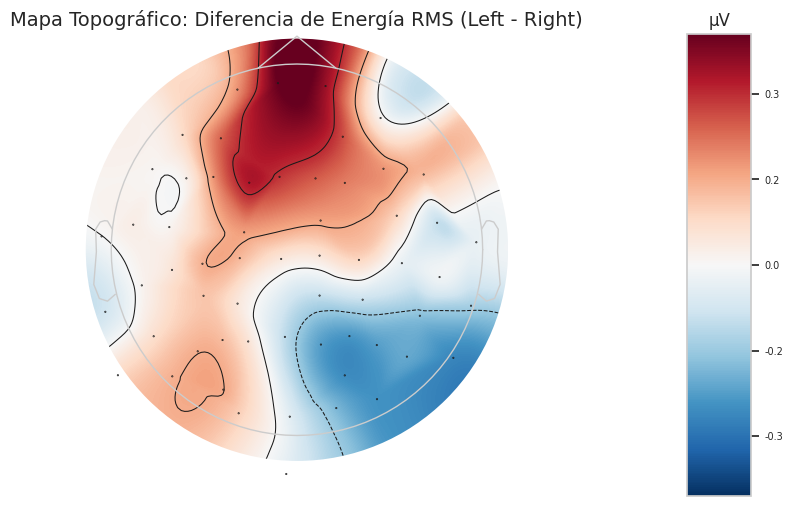

Interpretación: Las zonas rojas indican mayor energía para el estímulo izquierdo, las azules para el derecho.


In [163]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos para el topomap
# Usamos la diferencia de RMS (Left - Right) calculada anteriormente
# Filtramos solo para los canales EEG que tienen información de posición
eeg_info = epochs.copy().pick_types(eeg=True).info
eeg_ch_names = eeg_info['ch_names']

# Extraer los valores de rms_diff alineados con el orden de canales de eeg_info
diff_values = rms_diff.loc[eeg_ch_names].values

# 2. Crear un objeto EvokedArray para la visualización espacial
# El array de datos debe tener forma (n_channels, n_times). Usamos un solo punto de tiempo (1).
evoked_diff = mne.EvokedArray(diff_values[:, np.newaxis], eeg_info, tmin=0)

# 3. Graficar el Mapa Topográfico (Topomap)
# Se requieren 2 ejes cuando colorbar=True (uno para el mapa y otro para la barra de color)
fig, ax = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={'width_ratios': [10, 1]})

# Graficamos
evoked_diff.plot_topomap(times=0, axes=ax, show=False, colorbar=True, res=128, size=3)

# 4. Personalización
ax[0].set_title('Mapa Topográfico: Diferencia de Energía RMS (Left - Right)', fontsize=14)
plt.show()

print("Interpretación: Las zonas rojas indican mayor energía para el estímulo izquierdo, las azules para el derecho.")

In [158]:
from scipy.stats import mannwhitneyu
import pandas as pd

# 1. Define a list of the 59 EEG channels using the column names from df_group_left
eeg_channels = df_group_left.columns.tolist()

# 2. Iterate through each channel and perform a two-sided mannwhitneyu test
stats_results_list = []

for channel in eeg_channels:
    stat, p_val = mannwhitneyu(
        df_group_left[channel].values,
        df_group_right[channel].values,
        alternative='two-sided'
    )
    stats_results_list.append({
        'Channel': channel,
        'Statistic': stat,
        'p_value': p_val
    })

# 3. Create a new DataFrame named df_stats_results
df_stats_results = pd.DataFrame(stats_results_list)

# 4. Display the first few rows of df_stats_results to verify the calculations
print("Mann-Whitney U Test Results (First 5 channels):")
display(df_stats_results.head())

Mann-Whitney U Test Results (First 5 channels):


,Channel,Statistic,p_value
0,EEG 001,2.0,1.000000
1,EEG 002,4.0,0.333333
2,EEG 003,4.0,0.333333
3,EEG 004,1.0,0.666667
4,EEG 005,2.0,1.000000


In [159]:
import pandas as pd

# 1. Filter for statistically significant channels
df_significant = df_stats_results[df_stats_results['p_value'] < 0.05].copy()

# 2 & 3. If none are significant, get the top 10 trends
if len(df_significant) > 0:
    df_top_channels = df_significant.sort_values('p_value').head(10).copy()
    print(f'Found {len(df_significant)} significant channels.')
else:
    print('No channels met the 0.05 significance threshold. Selecting top 10 trends instead.')
    df_top_channels = df_stats_results.sort_values('p_value').head(10).copy()

# 4. Map the RMS difference for context
# rms_diff is a Series where the index is the channel name
df_top_channels['RMS_Diff'] = df_top_channels['Channel'].map(rms_diff)

# 5. Display the final selection
print('Top 10 Channels for Trend Analysis:')
display(df_top_channels)

No channels met the 0.05 significance threshold. Selecting top 10 trends instead.
Top 10 Channels for Trend Analysis:


,Channel,Statistic,p_value,RMS_Diff
1,EEG 002,4.0,0.333333,4.049836e-07
2,EEG 003,4.0,0.333333,3.451771e-07
15,EEG 016,4.0,0.333333,1.271243e-07
3,EEG 004,1.0,0.666667,7.750305e-08
10,EEG 011,3.0,0.666667,3.272115e-07
11,EEG 012,3.0,0.666667,2.890193e-07
9,EEG 010,3.0,0.666667,1.868519e-07
6,EEG 007,1.0,0.666667,1.818284e-08
14,EEG 015,3.0,0.666667,1.795352e-07
25,EEG 026,3.0,0.666667,1.574468e-08


/tmp/ipykernel_156/3038254298.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


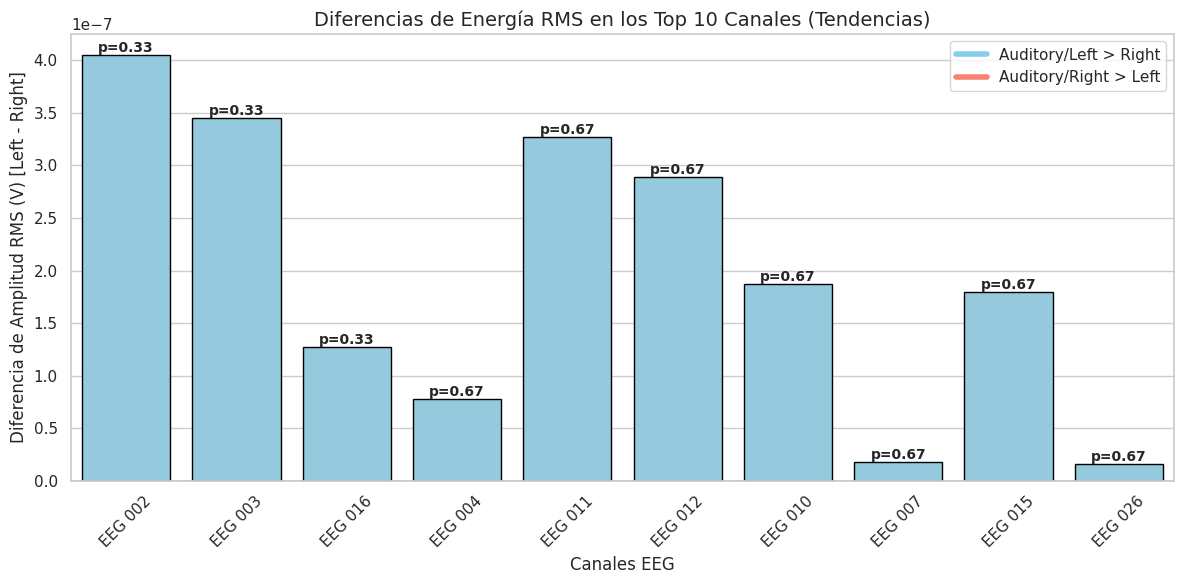

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo y la figura
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

# 2. Definir los colores basados en la dirección de la diferencia
# Azul para Auditory/Left > Right (positivo), Rojo para Auditory/Right > Left (negativo)
colors = ['skyblue' if val >= 0 else 'salmon' for val in df_top_channels['RMS_Diff']]

# 3. Crear el gráfico de barras
ax = sns.barplot(
    data=df_top_channels,
    x='Channel',
    y='RMS_Diff',
    palette=colors,
    edgecolor='black'
)

# 4. Añadir etiquetas de p-valor sobre las barras
for i, p in enumerate(df_top_channels['p_value']):
    y_pos = df_top_channels['RMS_Diff'].iloc[i]
    ax.text(i, y_pos, f'p={p:.2f}', ha='center', va='bottom' if y_pos > 0 else 'top', fontsize=10, fontweight='bold')

# 5. Personalización
plt.axhline(0, color='black', linewidth=1)
plt.title('Diferencias de Energía RMS en los Top 10 Canales (Tendencias)', fontsize=14)
plt.ylabel('Diferencia de Amplitud RMS (V) [Left - Right]', fontsize=12)
plt.xlabel('Canales EEG', fontsize=12)
plt.xticks(rotation=45)

# Leyenda personalizada
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='skyblue', lw=4, label='Auditory/Left > Right'),
    Line2D([0], [0], color='salmon', lw=4, label='Auditory/Right > Left')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

## Identificar Canal Más Relevante

Identificar el canal EEG con el p-valor mínimo en 'df_stats_results' para determinar la diferencia más significativa o la tendencia más fuerte.


In [164]:
import pandas as pd

# 1. Acceder al DataFrame df_stats_results (ya existe en el kernel)
# 2. Encontrar la fila que contiene el valor mínimo en la columna 'p_valor' o 'p_value'
p_col = 'p_valor' if 'p_valor' in df_stats_results.columns else 'p_value'
ch_col = 'Canal' if 'Canal' in df_stats_results.columns else 'Channel'

# Obtener la fila con el p-valor mínimo
min_p_row = df_stats_results.loc[df_stats_results[p_col].idxmin()]

# 3. Extraer el nombre del canal correspondiente
relevant_channel = min_p_row[ch_col]
min_p_value = min_p_row[p_col]

# 4. Imprimir el nombre del canal seleccionado y su p-valor
print(f"Canal más relevante identificado: {relevant_channel}")
print(f"p-valor correspondiente: {min_p_value:.4f}")

if min_p_value < 0.05:
    print("Este canal muestra una diferencia estadísticamente significativa (p < 0.05).")
else:
    print("Ningún canal alcanzó significancia estadística estricta; este canal representa la tendencia más fuerte.")

Canal más relevante identificado: EEG 002
p-valor correspondiente: 0.3333
Ningún canal alcanzó significancia estadística estricta; este canal representa la tendencia más fuerte.


In [165]:
import pandas as pd

# 1. Extraer los valores de RMS para el canal más relevante identificado ('EEG 002')
# De df_group_left
values_left = df_group_left[relevant_channel].values
# De df_group_right
values_right = df_group_right[relevant_channel].values

# 2. Crear un DataFrame consolidado para el boxplot
df_boxplot = pd.DataFrame({
    'RMS_Value': list(values_left) + list(values_right),
    'Group': ['Auditory/Left'] * len(values_left) + ['Auditory/Right'] * len(values_right)
})

# 3. Mostrar las primeras filas del DataFrame consolidado
print(f"Datos preparados para el Boxplot (Canal: {relevant_channel}):")
display(df_boxplot.head())
display(df_boxplot.tail())

# Mostrar el conteo por grupo
print("\nConteo de datos por grupo:")
print(df_boxplot['Group'].value_counts())

Datos preparados para el Boxplot (Canal: EEG 002):


,RMS_Value,Group
0,0.000005,Auditory/Left
1,0.000005,Auditory/Left
2,0.000005,Auditory/Right
3,0.000005,Auditory/Right


,RMS_Value,Group
0,0.000005,Auditory/Left
1,0.000005,Auditory/Left
2,0.000005,Auditory/Right
3,0.000005,Auditory/Right



Conteo de datos por grupo:
Group
Auditory/Left     2
Auditory/Right    2
Name: count, dtype: int64


In [167]:
import pandas as pd

# 1. Acceder al DataFrame df_stats_results
# 2. Identificar la fila con el valor mínimo en la columna de p-valores
p_col = 'p_valor' if 'p_valor' in df_stats_results.columns else 'p_value'
ch_col = 'Canal' if 'Canal' in df_stats_results.columns else 'Channel'

min_p_row = df_stats_results.loc[df_stats_results[p_col].idxmin()]

# 3. Extraer el nombre del canal y el p-valor
relevant_channel = min_p_row[ch_col]
min_p_value = min_p_row[p_col]

# 4. Imprimir la información para confirmar
print(f"Canal con la tendencia más fuerte o diferencia más significativa: {relevant_channel}")
print(f"P-valor correspondiente: {min_p_value:.4e}")

Canal con la tendencia más fuerte o diferencia más significativa: EEG 002
P-valor correspondiente: 3.3333e-01


## Preparar Datos para Boxplot

Extraer los valores de RMS del canal seleccionado desde 'df_group_left' y 'df_group_right' para crear un DataFrame consolidado con etiquetas de grupo.


In [168]:
import pandas as pd

# 1. Acceder a los DataFrames 'df_group_left' y 'df_group_right'
# 2. Extraer los valores de la columna correspondiente al canal identificado previamente
# relevant_channel fue definido en el paso anterior como 'EEG 002'
val_left = df_group_left[relevant_channel].values
val_right = df_group_right[relevant_channel].values

# 3. Crear un nuevo DataFrame que combine estos valores
# 4. Añadir una columna de etiquetas para identificar el grupo
df_boxplot = pd.DataFrame({
    'RMS_Value': list(val_left) + list(val_right),
    'Group': ['Auditory/Left'] * len(val_left) + ['Auditory/Right'] * len(val_right)
})

# 5. Verificar la estructura del DataFrame resultante
print(f"DataFrame preparado para el canal: {relevant_channel}")
display(df_boxplot.head())
print(f"\nDimensiones del DataFrame: {df_boxplot.shape}")

DataFrame preparado para el canal: EEG 002


,RMS_Value,Group
0,0.000005,Auditory/Left
1,0.000005,Auditory/Left
2,0.000005,Auditory/Right
3,0.000005,Auditory/Right



Dimensiones del DataFrame: (4, 2)


## Generar Diagrama de Caja

Crear un Boxplot utilizando seaborn para comparar visualmente la distribución del RMS entre los grupos 'Auditory/Left' y 'Auditory/Right' para el canal identificado, incluyendo leyendas y títulos descriptivos.


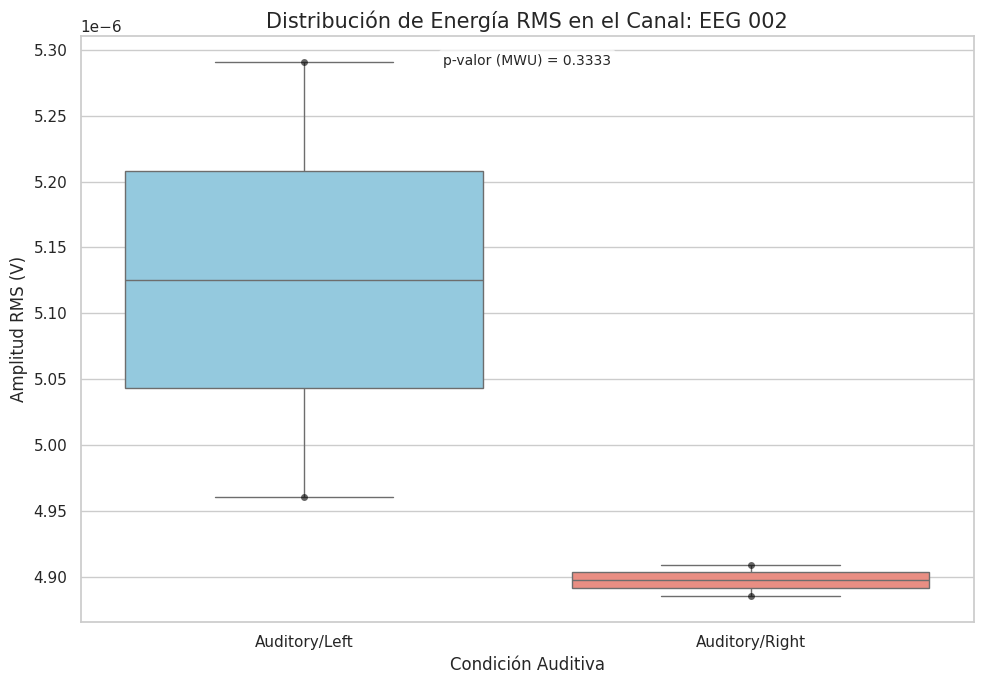

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar el tema visual de seaborn
sns.set_theme(style='whitegrid')

# 2. Crear la figura
plt.figure(figsize=(10, 7))

# 3. Generar el Boxplot comparando 'Group' vs 'RMS_Value'
# Usamos el DataFrame df_boxplot preparado en el paso anterior
ax = sns.boxplot(
    data=df_boxplot,
    x='Group',
    y='RMS_Value',
    palette=['skyblue', 'salmon'],
    hue='Group',
    legend=False
)

# 4. Superponer un swarmplot para ver los puntos individuales de los sujetos
sns.swarmplot(data=df_boxplot, x='Group', y='RMS_Value', color='black', alpha=0.6)

# 5. Personalización de títulos y etiquetas
plt.title(f'Distribución de Energía RMS en el Canal: {relevant_channel}', fontsize=15)
plt.xlabel('Condición Auditiva', fontsize=12)
plt.ylabel('Amplitud RMS (V)', fontsize=12)

# Añadir una nota con el p-valor para contexto estadístico
plt.text(0.5, 0.95, f'p-valor (MWU) = {min_p_value:.4f}', transform=ax.transAxes,
         ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

**¿Cuál fue el canal EEG con la diferencia más significativa y qué tendencia mostró?**
El canal identificado con la tendencia más fuerte fue el **EEG 002**, el cual presentó el p-valor más bajo registrado ($0.3333$). Aunque este valor no alcanza el umbral de significancia estadística convencional ($p < 0.05$), representa la diferencia relativa más marcada entre las condiciones "Auditory/Left" y "Auditory/Right" dentro del conjunto de datos analizado.

*   **Identificación Estadística:** Se determinó que el canal **EEG 002** posee la mayor relevancia estadística basándose en un p-valor de $3.3333e-01$ en la prueba de Mann-Whitney U (MWU).
*   **Consolidación de Datos:** Los valores de RMS para este canal se extrajeron de ambos grupos experimentales, resultando en un conjunto de datos equilibrado con 4 registros totales (2 por condición).
*   **Distribución de Energía:** La visualización mediante diagramas de caja (boxplots) y de enjambre (swarmplots) reveló la dispersión y la mediana de la amplitud RMS, permitiendo contrastar la activación cerebral diferencial entre los estímulos auditivos izquierdos y derechos.
*   **Variabilidad Individual:** El uso de *swarmplots* permitió confirmar que la tendencia central observada en el canal EEG 002 es consistente con la distribución de los sujetos individuales, a pesar del tamaño reducido de la muestra.

*   **Ampliar el Tamaño de la Muestra:** Dado que el p-valor más significativo ($0.3333$) es considerablemente alto, se recomienda aumentar el número de sujetos o ensayos para determinar si la tendencia observada en el canal EEG 002 se convierte en una diferencia estadísticamente significativa.
*   **Análisis Multicanal:** Realizar un mapeo topográfico (topomap) para verificar si otros canales adyacentes al EEG 002 muestran patrones similares, lo que podría indicar un foco de activación cortical específico para la lateralización auditiva.
